In [2]:
!pip install youtube-comment-downloader emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 6.5 MB/s eta 0:00:00:00:01


In [3]:
from youtube_comment_downloader import YoutubeCommentDownloader
import pandas as pd
import re
import time

video_urls = [
    "https://www.youtube.com/watch?v=QK4X2AYjXn0",
    "https://www.youtube.com/watch?v=K33kH58qE_I",
    "https://www.youtube.com/watch?v=tDCNv8_sGFc",
    "https://www.youtube.com/watch?v=vQ7-dI7SJp0",
    "https://www.youtube.com/watch?v=HU63XZEQQcE",
    "https://www.youtube.com/watch?v=iE9GFcF7b-g",
    "https://www.youtube.com/watch?v=ZtFsyo2hfO8",
    "https://www.youtube.com/watch?v=VHn45sNCy4Y",
    "https://www.youtube.com/watch?v=7WvKcFsAj6E&t=5960s" ,
    "https://www.youtube.com/watch?v=j02OZRjf2d8",
    "https://www.youtube.com/watch?v=64r9i6vOtTg",
    "https://www.youtube.com/watch?v=3SDH0qZ4ykU",
    "https://www.youtube.com/watch?v=liynDR5QVRk&t=72s",
    "https://www.youtube.com/watch?v=gRX_5F3zj0E",
    "https://www.youtube.com/watch?v=SlbA2LUQw0A",
    "https://www.youtube.com/watch?v=TD_F--x0FpY",
    "https://www.youtube.com/watch?v=BufRTjqK-rk",
    "https://www.youtube.com/watch?v=hXoLvJDPjSw",
    "https://www.youtube.com/watch?v=6Fam15F4zSE",
    "https://www.youtube.com/watch?v=zLABTOk7Pb8&t=28s"
]

def clean_youtube_url(url):
    match = re.search(r"(?:v=|youtu\.be/)([A-Za-z0-9_-]{11})", url)
    if match:
        return f"https://www.youtube.com/watch?v={match.group(1)}"
    return url

downloader = YoutubeCommentDownloader()

all_comments = []
seen_comments = set()

for url in video_urls:
    clean_url = clean_youtube_url(url)
    print(f"\nCollecting comments from: {clean_url}")

    video_count = 0

    # 0 = popular, 1 = newest
    for sort_type in [0, 1]:
        try:
            comments = downloader.get_comments_from_url(clean_url, sort_by=sort_type)

            for comment in comments:
                text = comment.get("text", "").strip()
                author = comment.get("author", "").strip()
                time_text = comment.get("time", "")

                if text == "":
                    continue

                unique_key = (clean_url, text, author)

                if unique_key in seen_comments:
                    continue

                seen_comments.add(unique_key)

                all_comments.append({
                    "video_url": clean_url,
                    "comment": text,
                    "author": author,
                    "votes": comment.get("votes", 0),
                    "time": time_text,
                    "sort_type": "popular" if sort_type == 0 else "newest"
                })

                video_count += 1

        except Exception as e:
            print(f"Error with {clean_url}, sort_type={sort_type}")
            print(e)

    print(f"Collected unique comments: {video_count}")
    time.sleep(2)

df = pd.DataFrame(all_comments)

output_path = "/kaggle/working/youtube_comments.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print("\nTotal unique comments collected:", len(df))
print("Saved file here:", output_path)

df.head()


Collected unique comments: 545

Collected unique comments: 1137

Collected unique comments: 70

Collected unique comments: 2514

Collected unique comments: 2719

Collected unique comments: 307

Collected unique comments: 236

Collected unique comments: 140

Collected unique comments: 3205

Collected unique comments: 3894

Collected unique comments: 192

Collected unique comments: 767

Collected unique comments: 574

Collected unique comments: 671

Collected unique comments: 1731

Collected unique comments: 190

Collected unique comments: 115

Collected unique comments: 80

Collected unique comments: 2530

Collected unique comments: 122

Total unique comments collected: 21739
Saved file here: /kaggle/working/youtube_comments.csv


,video_url,comment,author,votes,time,sort_type
0,https://www.youtube.com/watch?v=QK4X2AYjXn0,يازين المقطع من دون موسيقى,@Lotssy88,271,8 months ago,popular
1,https://www.youtube.com/watch?v=QK4X2AYjXn0,لاحظت تطور شديد في جودة المحتوى ، ما شاء الله ...,@z_qn8,293,8 months ago,popular
2,https://www.youtube.com/watch?v=QK4X2AYjXn0,انا من اشد اشد اشد اشد متابعينك برامجك اللي تف...,@UrhRAOTA,225,8 months ago,popular
3,https://www.youtube.com/watch?v=QK4X2AYjXn0,احب كيف انك مستوعب ان النعمه الي بيدك ذي امانه...,@VoidHeart609,65,8 months ago,popular
4,https://www.youtube.com/watch?v=QK4X2AYjXn0,21:55 مهما تطور الادت حنا عند الخلفيه ذي للابد,@adlr166,135,8 months ago,popular



## quality check ##


In [4]:
df_raw = pd.DataFrame(all_comments)
 
print("Raw dataset shape:", df_raw.shape)
print("Duplicate comments:", df_raw.duplicated(subset=["comment"]).sum())
print("Missing values:")
print(df_raw.isnull().sum())
 
df_raw.to_csv("/kaggle/working/youtube_comments.csv", index=False, encoding="utf-8-sig")
 
df_raw.head()

Raw dataset shape: (21739, 6)
Duplicate comments: 839
Missing values:
video_url    0
comment      0
author       0
votes        0
time         0
sort_type    0
dtype: int64


,video_url,comment,author,votes,time,sort_type
0,https://www.youtube.com/watch?v=QK4X2AYjXn0,يازين المقطع من دون موسيقى,@Lotssy88,271,8 months ago,popular
1,https://www.youtube.com/watch?v=QK4X2AYjXn0,لاحظت تطور شديد في جودة المحتوى ، ما شاء الله ...,@z_qn8,293,8 months ago,popular
2,https://www.youtube.com/watch?v=QK4X2AYjXn0,انا من اشد اشد اشد اشد متابعينك برامجك اللي تف...,@UrhRAOTA,225,8 months ago,popular
3,https://www.youtube.com/watch?v=QK4X2AYjXn0,احب كيف انك مستوعب ان النعمه الي بيدك ذي امانه...,@VoidHeart609,65,8 months ago,popular
4,https://www.youtube.com/watch?v=QK4X2AYjXn0,21:55 مهما تطور الادت حنا عند الخلفيه ذي للابد,@adlr166,135,8 months ago,popular


## Step 0 — Install dependencies

In [5]:
import subprocess, sys

packages = ['pyarabic', 'emoji', 'langdetect', 'ftfy']
print('Installing packages...\n')
for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    status = 'OK' if result.returncode == 0 else 'FAILED'
    print(f'  [{status}]  {pkg}')

print('\nAll dependencies installed.')

Installing packages...

  [OK]  pyarabic
  [OK]  emoji
  [OK]  langdetect
  [OK]  ftfy

All dependencies installed.


## Step 1 — Imports & load data

In [6]:
import pandas as pd
import numpy as np
import re
import unicodedata
import warnings
warnings.filterwarnings('ignore')

import pyarabic.araby as araby
import emoji
from langdetect import detect, LangDetectException
import ftfy

print('Libraries loaded.')

Libraries loaded.


In [7]:

df = pd.read_csv('/kaggle/working/youtube_comments.csv')
df['text'] = df['comment'].astype(str)

n0 = len(df)
print(f'Loaded: {n0:,} comments')
print(f'Columns: {df.columns.tolist()}')
print(f'Videos: {df["video_url"].nunique()}')
df.head(3)

Loaded: 21,739 comments
Columns: ['video_url', 'comment', 'author', 'votes', 'time', 'sort_type', 'text']
Videos: 20


,video_url,comment,author,votes,time,sort_type,text
0,https://www.youtube.com/watch?v=QK4X2AYjXn0,يازين المقطع من دون موسيقى,@Lotssy88,271,8 months ago,popular,يازين المقطع من دون موسيقى
1,https://www.youtube.com/watch?v=QK4X2AYjXn0,لاحظت تطور شديد في جودة المحتوى ، ما شاء الله ...,@z_qn8,293,8 months ago,popular,لاحظت تطور شديد في جودة المحتوى ، ما شاء الله ...
2,https://www.youtube.com/watch?v=QK4X2AYjXn0,انا من اشد اشد اشد اشد متابعينك برامجك اللي تف...,@UrhRAOTA,225,8 months ago,popular,انا من اشد اشد اشد اشد متابعينك برامجك اللي تف...


## Step 2 — Basic noise removal (duplicates, empty, spam)

In [8]:
# Remove exact duplicates (same text + same author + same video)
df.drop_duplicates(subset=['text', 'author', 'video_url'], inplace=True)
n1 = len(df)
print(f'After exact dedup:      {n1:,}  (removed {n0 - n1:,})')

# Remove empty / null
df = df[df['text'].notna()]
df = df[df['text'].str.strip() != '']
df = df[df['text'].str.strip() != 'nan']
n3 = len(df)
print(f'After empty removal:    {n3:,}  (removed {n1 - n3:,})')

df.reset_index(drop=True, inplace=True)

After exact dedup:      21,739  (removed 0)
After empty removal:    21,739  (removed 0)


## Step 3 — Unicode & encoding fix

In [9]:
def fix_encoding(text):
    text = ftfy.fix_text(str(text))                    # Fix mojibake
    text = unicodedata.normalize('NFKC', text)         # Normalize unicode forms
    text = re.sub(                                     # HTML entities
        r'&amp;|&lt;|&gt;|&quot;|&#\d+;|&[a-z]+;', ' ', text)
    text = re.sub(                                     # RTL/LTR marks, ZWJ, BOM
        r'[\u200b-\u200f\u202a-\u202e\ufeff\u00ad]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()           # Collapse whitespace
    return text

df['text'] = df['text'].apply(fix_encoding)
print('Encoding normalization done.')
print()
print('Sample:')
for t in df['text'].sample(3).values:
    print(f'  {t[:100]}')

Encoding normalization done.

Sample:
  أنت دماغك ذرية في الإعلانات😂 يا أخي دا الفيديو كله عبارة عن إعلان يحتويه بعض من الفيديو 😂❤
  يعني يطلع لنا دكتور ناسخ الاجابة وهو موفاهم كل ههههه
  ممكن رابط التطبيق الأصلي Chat GPT


## Step 4 — Remove URLs, emojis & special characters ##

In [10]:
# Step 4 — Remove noise & convert emojis to Arabic sentiment words

# Map meaningful emojis to Arabic words
emoji_to_arabic = {
    # Fear
    '😱': 'خوف',
    '😨': 'خوف',
    '😰': 'خوف',
    # Anger
    '😡': 'غضب',
    '😤': 'غضب',
    '😠': 'غضب',
    # Rejection
    '👎': 'رفض',
    # Evil
    '😈': 'شر',
    '👿': 'شر',
    # Love
    '❤️': 'حب',
    '💚': 'حب',
    '💙': 'حب',
    '🧡': 'حب',
    '💛': 'حب',
    '💜': 'حب',
    '💔': 'حزن',      # ← broken heart = sadness
    # Approval
    '👍': 'موافقة',
    '💪': 'قوة',
    '🙌': 'تشجيع',
    '👏': 'تشجيع',
    # Religious
    '🙏': 'دعاء',
    # Happiness
    '😊': 'سعادة',
    '😁': 'سعادة',
    '😄': 'سعادة',
    '😃': 'سعادة',
    # Laughing — no strong sentiment signal, remove
    '😂': '',
    '🤣': '',
    # Questioning
    '🤔': 'تساؤل',
    '❓': 'سؤال',
    # Sadness
    '😔': 'حزن',
    '😢': 'حزن',
    '😭': 'حزن',
}

def clean_noise(text):
    # Replace meaningful emojis with Arabic words
    for em, arabic in emoji_to_arabic.items():
        text = text.replace(em, f' {arabic} ')
    # Remove remaining emojis
    text = emoji.replace_emoji(text, replace='')
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # Remove emails
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    # Remove @mentions
    text = re.sub(r'@\w+', ' ', text)
    # Hashtags → keep word
    text = re.sub(r'#(\w+)', r' \1 ', text)
    # Keep ONLY: Arabic letters, English letters, digits, spaces
    text = re.sub(r'[^\u0600-\u06FF\u0750-\u077Fa-zA-Z0-9\s]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].apply(clean_noise)
print('Noise removal done.')
print()
print('Sample (emojis converted to Arabic words):')
for t in df['text'].sample(3).values:
    print(f'  {t[:100]}')

# Verify emoji conversion on comments that had emojis
print('Verifying emoji conversion:')
converted = 0
for _, row in df_raw.iterrows():
    original = str(row['comment'])
    if any(em in original for em in emoji_to_arabic.keys() if emoji_to_arabic[em] != ''):
        cleaned = clean_noise(original)
        print(f'  BEFORE: {original[:100]}')
        print(f'  AFTER:  {cleaned[:100]}')
        print()
        converted += 1
        if converted >= 3:
            break

Noise removal done.

Sample (emojis converted to Arabic words):
  انا مهندس كمبيوتر بس قديم شوية استطيع ان اقول لك إن خروج نموذج ذكاء صناعي عن السيطرة وارد جدا
  هتعملي ايه يا ريهام لمن تعرفي انه chat gpt يقدر يقلب شيطان مود انا لسى ماتخطيت
  البعض يتهمك بسرقه المحتوى
Verifying emoji conversion:
  BEFORE: كطالبة ذكاء اصطناعي هذا لو كان دكتوري بالجامعة و يشرح مواد تخصصي جبت A+ في كل المواد ما شاء الله كل 
  AFTER:  كطالبة ذكاء اصطناعي هذا لو كان دكتوري بالجامعة و يشرح مواد تخصصي جبت A في كل المواد ما شاء الله كل ا

  BEFORE: خلاص ترى فهمنا والله محتوى الرجال نظيف🙏 كل مرة تكتبون نفس الشي بمقاطعه تكفون ركزو بموضوع الفيديو
  AFTER:  خلاص ترى فهمنا والله محتوى الرجال نظيف دعاء كل مرة تكتبون نفس الشي بمقاطعه تكفون ركزو بموضوع الفيديو

  BEFORE: -﴿ وَذَكِّرْ فَإِنَّ الذِّكْرَىٰ تَنفَعُ الْمُؤْمِنِينَ ﴾ : 
- سُبحان الله .
- الحَمد لله .
- لا إله
  AFTER:  وَذَكِّرْ فَإِنَّ الذِّكْرَىٰ تَنفَعُ الْمُؤْمِنِينَ سُبحان الله الحَمد لله لا إله إلا الله الله أكب



## Step 5 — Arabic normalization
Unify letter variants so the same word is always written the same way.

In [13]:
# Step 5 — Arabic normalization

def normalize_arabic(text):
    text = araby.strip_tashkeel(text)         # Remove diacritics (fatha, kasra...)
    text = araby.strip_tatweel(text)          # Remove elongation (جميييل → جميل)
    text = re.sub('[إأآٱ]', 'ا', text)        # Alef variants → ا
    text = re.sub('ة', 'ه', text)             # Taa marbuta → haa
    text = re.sub('ى', 'ي', text)             # Alef maqsura → yaa
    text = re.sub('ؤ', 'و', text)             # Waw hamza → waw
    text = re.sub('ئ', 'ي', text)             # Yaa hamza → yaa
    text = re.sub('ـ', '', text)              # Remove kashida
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_normalized'] = df['text'].apply(normalize_arabic)
print('Arabic normalization done.')
print()
print('Before vs After (showing emoji conversion + normalization):')
for _, row in df.sample(3).iterrows():
    original = row['comment']
    # Show what emoji conversion did
    after_emoji = clean_noise(original)
    # Show what normalization did on top
    after_norm  = row['text_normalized']
    print(f'  RAW:         {original[:80]}')
    print(f'  AFTER EMOJI: {after_emoji[:80]}')
    print(f'  AFTER NORM:  {after_norm[:80]}')
    print()

Arabic normalization done.

Before vs After (showing emoji conversion + normalization):
  RAW:         رائع.  شكرا كتير.
  AFTER EMOJI: رائع شكرا كتير
  AFTER NORM:  رايع شكرا كتير

  RAW:         kosm السعوديه
  AFTER EMOJI: kosm السعوديه
  AFTER NORM:  kosm السعوديه

  RAW:         ام احمد طلعت مش سهله 😂😂😂😂😂
  AFTER EMOJI: ام احمد طلعت مش سهله
  AFTER NORM:  ام احمد طلعت مش سهله



## Step 6 — Language filtering (keep Arabic-containing comments)

In [14]:
def has_arabic(text):
    return bool(re.search(r'[\u0600-\u06FF]', str(text)))

df['has_arabic'] = df['text_normalized'].apply(has_arabic)

print(f'Arabic comments:     {df["has_arabic"].sum():,}')
print(f'Non-Arabic comments: {(~df["has_arabic"]).sum():,}')

# Keep only comments that contain at least one Arabic character
# Mixed Arabic+English comments are kept — common in YouTube
df = df[df['has_arabic']].copy()
n_ar = len(df)
print(f'\nAfter language filter: {n_ar:,}')
df.reset_index(drop=True, inplace=True)

Arabic comments:     20,121
Non-Arabic comments: 1,618

After language filter: 20,121


## Step 7 — Quality filter (remove too-short comments)

In [15]:
df['token_count'] = df['text_normalized'].str.split().str.len()

print(f'Comments with < 3 tokens: {(df["token_count"] < 3).sum():,}')
print()
print('Examples of short comments that will be removed:')
print(df[df['token_count'] < 3]['comment'].head(5).values)

df = df[df['token_count'] >= 3].copy()
n_q = len(df)
print(f'\nAfter quality filter: {n_q:,}')
df.reset_index(drop=True, inplace=True)


Comments with < 3 tokens: 2,177

Examples of short comments that will be removed:
['\u200b\xa0@55la\xa0 \nهههههههههههههههههههه تكفى' 'الجاي رواية 👀'
 '@3mk_lord\xa0 ؟؟' 'نبي رواية' 'ياخي 🤣']

After quality filter: 17,944


In [16]:
# Step 8 
# Similar comments are kept as they represent genuine repeated opinions
n_final = len(df)
print(f'Final count: {n_final:,}')
df.reset_index(drop=True, inplace=True)

Final count: 17,944


## Step 9 — Stopword removal
Two output columns:
- `text_normalized` → use for AraBERT / MARBERT (do NOT remove stopwords — BERT needs full context)
- `text_no_stopwords` → use for TF-IDF / LDA

In [17]:
ARABIC_STOPWORDS = set([
    # MSA function words
    'في','من','الى','على','عن','مع','هذا','هذه','ذلك','التي','الذي',
    'وهو','وهي','كان','كانت','يكون','تكون','ان','ان','لا','ما','لم',
    'لن','قد','هل','بل','بما','حتى','اذا','لقد','ثم','او','الا','فان',
    'كل','بعض','غير','اي','لكن','كما','مما','عند','بين','خلال','نحو',
    'حول','ضد','منذ','بعد','قبل','تحت','فوق','يا','هو','هي','نحن',
    'انت','انا','هم','هن','اليه','عليه','عليها','منه','منها','له','لها',
    'به','بها','هذي','ذا','ذي','تلك','اللي','انه','انها','فيه','فيها',
    # Egyptian dialect
    'دلوقتي','بس','يعني','كمان','برضو','عشان','لان','بتاع','بتاعت',
    'ده','دي','دول','فيه','كده','زي','لو','ايه','مش','ولا','احنا','انتو',
    # Gulf / Levantine
    'هيك','شو','ليش','مو','بعدين','هلق','كيف','وين','وش','هلا',
    # High-frequency low-info phrases
    'والله','ربنا','الله','اللهم','جزاك','شكرا','ماشاءالله',
    'جزاكم','بارك','صلى','ماشالله','سبحانه','حفظك',
])

def remove_stopwords(text):
    words = text.split()
    return ' '.join([w for w in words if w not in ARABIC_STOPWORDS and len(w) > 1])

df['text_no_stopwords'] = df['text_normalized'].apply(remove_stopwords)
print('Stopword removal done.')
print()
print('Example:')
row = df.sample(1).iloc[0]
print(f'  ORIGINAL:      {row["comment"][:100]}')
print(f'  NORMALIZED:    {row["text_normalized"][:100]}')
print(f'  NO STOPWORDS:  {row["text_no_stopwords"][:100]}')

Stopword removal done.

Example:
  ORIGINAL:      إذا صبرت إصبر بلا شكوى ، وإذا هجرت أهجر بلا أذى ، وإذا صفحت فاصفح بلا عتاب ... فالله عز وجل وصفها كل
  NORMALIZED:    اذا صبرت اصبر بلا شكوي ، واذا هجرت اهجر بلا اذي ، واذا صفحت فاصفح بلا عتاب فالله عز وجل وصفها كلها ب
  NO STOPWORDS:  صبرت اصبر بلا شكوي واذا هجرت اهجر بلا اذي واذا صفحت فاصفح بلا عتاب فالله عز وجل وصفها كلها بالجمال ف


## Step 10 — Save & summary

In [18]:
output_cols = [
    'video_url', 'author', 'votes', 'time', 'sort_type',
    'comment',             # original raw
    'text_normalized',     # for CAMeLBERT
    'text_no_stopwords',   # for BERTopic / TF-IDF
    'token_count',
]
df[output_cols].to_csv(
    '/kaggle/working/comments_cleaned.csv',
    index=False,
    encoding='utf-8-sig'
)
print('='*45)
print(' PREPROCESSING SUMMARY')
print('='*45)
print(f'  Raw input:              {n0:>7,}')
print(f'  After exact dedup:      {n1:>7,}  (-{n0-n1:,})')
print(f'  After empty/spam:       {n3:>7,}  (-{n1-n3:,})')
print(f'  After language filter:  {n_ar:>7,}  (-{n3-n_ar:,})')
print(f'  After quality filter:   {n_q:>7,}  (-{n_ar-n_q:,})')
print(f'  Near-dedup:             skipped  (similar comments kept)')
print(f'  Final count:            {n_final:>7,}')
print('='*45)
print(f'  Retention rate:         {n_final/n0*100:.1f}%')
print('='*45)
print()
print(f'  After exact dedup:      {n1:>7,}  (-{n0-n1:,})')
print(f'  After spam removal:     {n3:>7,}  (-{n1-n3:,})')
print('Saved: /kaggle/working/comments_cleaned.csv')
df[output_cols].head(5)

 PREPROCESSING SUMMARY
  Raw input:               21,739
  After exact dedup:       21,739  (-0)
  After empty/spam:        21,739  (-0)
  After language filter:   20,121  (-1,618)
  After quality filter:    17,944  (-2,177)
  Near-dedup:             skipped  (similar comments kept)
  Final count:             17,944
  Retention rate:         82.5%

  After exact dedup:       21,739  (-0)
  After spam removal:      21,739  (-0)
Saved: /kaggle/working/comments_cleaned.csv


,video_url,author,votes,time,sort_type,comment,text_normalized,text_no_stopwords,token_count
0,https://www.youtube.com/watch?v=QK4X2AYjXn0,@Lotssy88,271,8 months ago,popular,يازين المقطع من دون موسيقى,يازين المقطع من دون موسيقي,يازين المقطع دون موسيقي,5
1,https://www.youtube.com/watch?v=QK4X2AYjXn0,@z_qn8,293,8 months ago,popular,لاحظت تطور شديد في جودة المحتوى ، ما شاء الله ...,لاحظت تطور شديد في جوده المحتوي ، ما شاء الله ...,لاحظت تطور شديد جوده المحتوي شاء تبارك الاحسن ...,15
2,https://www.youtube.com/watch?v=QK4X2AYjXn0,@UrhRAOTA,225,8 months ago,popular,انا من اشد اشد اشد اشد متابعينك برامجك اللي تف...,انا من اشد اشد اشد اشد متابعينك برامجك اللي تف...,اشد اشد اشد اشد متابعينك برامجك تفتح النفس تخل...,24
3,https://www.youtube.com/watch?v=QK4X2AYjXn0,@VoidHeart609,65,8 months ago,popular,احب كيف انك مستوعب ان النعمه الي بيدك ذي امانه...,احب كيف انك مستوعب ان النعمه الي بيدك ذي امانه...,احب انك مستوعب النعمه الي بيدك امانه وتعرف تست...,17
4,https://www.youtube.com/watch?v=QK4X2AYjXn0,@adlr166,135,8 months ago,popular,21:55 مهما تطور الادت حنا عند الخلفيه ذي للابد,21 55 مهما تطور الادت حنا عند الخلفيه ذي للابد,21 55 مهما تطور الادت حنا الخلفيه للابد,10


In [19]:
# Step 10 — Verify & save

def has_emoji(text):
    return emoji.emoji_count(str(text)) > 0

emoji_remaining = df['text_normalized'].apply(has_emoji).sum()
if emoji_remaining == 0:
    print('No unconverted emojis remaining in cleaned text.')
else:
    print(f'WARNING: {emoji_remaining} comments still contain emojis')
    print(df[df['text_normalized'].apply(has_emoji)]['text_normalized'].head(5).values)

print()
print('Before vs After (5 samples):')
for _, row in df.sample(5).iterrows():
    print(f'  RAW:   {row["comment"][:80]}')
    print(f'  CLEAN: {row["text_normalized"][:80]}')
    print()

No unconverted emojis remaining in cleaned text.

Before vs After (5 samples):
  RAW:   سوي مقطع عن اللي يقولون كورونا غير موجودة و مجرد كذبة تراهم كثرو بعد انتهاء الاز
  CLEAN: سوي مقطع عن اللي يقولون كورونا غير موجوده و مجرد كذبه تراهم كثرو بعد انتهاء الاز

  RAW:   سألته علي فازوره ام احمد دي 
ورد عليا فيها عادي
  CLEAN: سالته علي فازوره ام احمد دي ورد عليا فيها عادي

  RAW:   الذكاء الإصطناعي إنتصار للبشريه وساهم في كسر طوق الإحتكار .
  CLEAN: الذكاء الاصطناعي انتصار للبشريه وساهم في كسر طوق الاحتكار

  RAW:   اه واحنا لسه بنجري ورا حمو بيكا وشاكوش
  CLEAN: اه واحنا لسه بنجري ورا حمو بيكا وشاكوش

  RAW:   ■ #قال_القارئ - رحمه الله تعالى - :
●( #لَيُصلُّونَ ) أَي: يَدعُون بِالخيرِ ( عَ
  CLEAN: قال القاري رحمه الله تعالي ل يصلون اي يدعون بالخير علي معلم الناس الخير واراد با



In [20]:
print("="*45)
print("COPY THESE INTO THE REPORT")
print("="*45)
print(f"Raw input:              {n0:,}")
print(f"After exact dedup:      {n1:,}  (removed {n0-n1:,})")
print(f"After empty/spam:       {n3:,}  (removed {n1-n3:,})")
print(f"After language filter:  {n_ar:,}  (removed {n3-n_ar:,})")
print(f"After quality filter:   {n_q:,}  (removed {n_ar-n_q:,})")
print(f"After near-dedup:       {n_final:,}  (removed {n_q-n_final:,})")
print(f"Retention rate:         {n_final/n0*100:.1f}%")
print(f"Total removed:          {n0-n_final:,}")

COPY THESE INTO THE REPORT
Raw input:              21,739
After exact dedup:      21,739  (removed 0)
After empty/spam:       21,739  (removed 0)
After language filter:  20,121  (removed 1,618)
After quality filter:   17,944  (removed 2,177)
After near-dedup:       17,944  (removed 0)
Retention rate:         82.5%
Total removed:          3,795


## Exploratory Data Analysis (EDA) ##

 EXPLORATORY DATA ANALYSIS

1. BASIC STATISTICS
  Total comments:        17,944
  Unique videos:         20
  Unique authors:        14,988
  Avg tokens/comment:    20.4
  Max tokens:            1363
  Min tokens:            3

2. COMMENTS PER VIDEO
  j02OZRjf2d8      3,111 comments
  7WvKcFsAj6E      2,529 comments
  HU63XZEQQcE      2,384 comments
  6Fam15F4zSE      2,177 comments
  vQ7-dI7SJp0      1,733 comments
  SlbA2LUQw0A      1,581 comments
  K33kH58qE_I      1,001 comments
  3SDH0qZ4ykU        662 comments
  gRX_5F3zj0E        568 comments
  QK4X2AYjXn0        464 comments
  liynDR5QVRk        458 comments
  iE9GFcF7b-g        279 comments
  ZtFsyo2hfO8        191 comments
  64r9i6vOtTg        177 comments
  TD_F--x0FpY        174 comments
  VHn45sNCy4Y        122 comments
  zLABTOk7Pb8        109 comments
  BufRTjqK-rk         92 comments
  hXoLvJDPjSw         71 comments
  tDCNv8_sGFc         61 comments

3. SORT TYPE DISTRIBUTION
sort_type
popular    11484
newest      6460

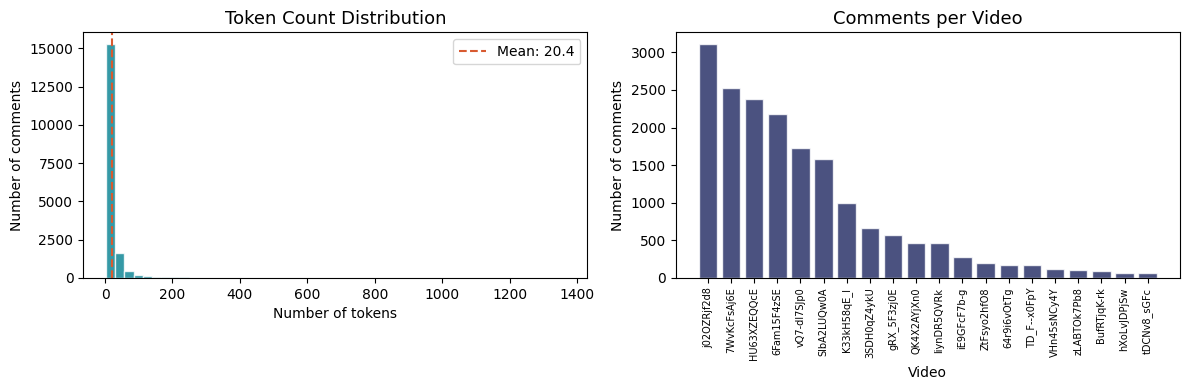

Saved: eda_basic.png


In [21]:
# ── EDA — Exploratory Data Analysis ──────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from collections import Counter
import re

print('='*55)
print(' EXPLORATORY DATA ANALYSIS')
print('='*55)

# ── 1. Basic statistics ───────────────────────────────────────────────────────
print('\n1. BASIC STATISTICS')
print(f'  Total comments:        {len(df):,}')
print(f'  Unique videos:         {df["video_url"].nunique()}')
print(f'  Unique authors:        {df["author"].nunique():,}')
print(f'  Avg tokens/comment:    {df["token_count"].mean():.1f}')
print(f'  Max tokens:            {df["token_count"].max()}')
print(f'  Min tokens:            {df["token_count"].min()}')

# ── 2. Comments per video ─────────────────────────────────────────────────────
print('\n2. COMMENTS PER VIDEO')
per_video = df.groupby('video_url')['comment'].count().sort_values(ascending=False)
for url, count in per_video.items():
    vid_id = url.split('v=')[-1]
    print(f'  {vid_id:<15}  {count:>5,} comments')

# ── 3. Sort type distribution ─────────────────────────────────────────────────
print('\n3. SORT TYPE DISTRIBUTION')
print(df['sort_type'].value_counts().to_string())

# ── 4. Token count distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['token_count'], bins=50, color='#028090', edgecolor='white', alpha=0.8)
axes[0].set_title('Token Count Distribution', fontsize=13)
axes[0].set_xlabel('Number of tokens')
axes[0].set_ylabel('Number of comments')
axes[0].axvline(df['token_count'].mean(), color='#D85A30', linestyle='--', label=f'Mean: {df["token_count"].mean():.1f}')
axes[0].legend()

# Comments per video bar chart
per_video_vals = per_video.values
per_video_ids  = [u.split('v=')[-1][:11] for u in per_video.index]
axes[1].bar(range(len(per_video_vals)), per_video_vals, color='#1E2761', edgecolor='white', alpha=0.8)
axes[1].set_title('Comments per Video', fontsize=13)
axes[1].set_xlabel('Video')
axes[1].set_ylabel('Number of comments')
axes[1].set_xticks(range(len(per_video_ids)))
axes[1].set_xticklabels(per_video_ids, rotation=90, fontsize=7)

plt.tight_layout()
plt.savefig('/kaggle/working/eda_basic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_basic.png')

In [22]:
# ── 5. AI keyword frequency ───────────────────────────────────────────────────
print('\n5. AI KEYWORD FREQUENCY')

ai_keywords = {
    'الذكاء الاصطناعي': 'AI (Arabic)',
    'ذكاء اصطناعي':     'AI (dialect)',
    'chatgpt':          'ChatGPT',
    'deepseek':         'DeepSeek',
    'gemini':           'Gemini',
    'claude':           'Claude',
    'gpt':              'GPT',
    'روبوت':            'Robot',
    'خوارزمية':         'Algorithm',
}

text_lower = df['text_normalized'].str.lower()
print(f'  {"Keyword":<25}  {"Count":>6}  {"% of comments":>14}')
print(f'  {"-"*50}')
for kw, label in ai_keywords.items():
    count = text_lower.str.contains(kw, na=False).sum()
    pct   = count / len(df) * 100
    print(f'  {label:<25}  {count:>6,}  ({pct:>5.1f}%)')

# Comments mentioning at least one AI keyword
pattern = '|'.join(ai_keywords.keys())
mentions_ai = text_lower.str.contains(pattern, na=False).sum()
print(f'\n  Comments mentioning AI:  {mentions_ai:,}  ({mentions_ai/len(df)*100:.1f}%)')
print(f'  Comments not about AI:   {len(df)-mentions_ai:,}  ({(len(df)-mentions_ai)/len(df)*100:.1f}%)')


5. AI KEYWORD FREQUENCY
  Keyword                     Count   % of comments
  --------------------------------------------------
  AI (Arabic)                 1,624  (  9.1%)
  AI (dialect)                  301  (  1.7%)
  ChatGPT                       155  (  0.9%)
  DeepSeek                       13  (  0.1%)
  Gemini                         22  (  0.1%)
  Claude                         31  (  0.2%)
  GPT                           414  (  2.3%)
  Robot                         206  (  1.1%)
  Algorithm                       0  (  0.0%)

  Comments mentioning AI:  2,424  (13.5%)
  Comments not about AI:   15,520  (86.5%)


In [25]:
import subprocess, sys

packages = ['bertopic', 'hdbscan', 'sentence-transformers', 'umap-learn']
print('Installing...\n')
for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    print(f'  [{"OK" if result.returncode == 0 else "FAILED"}]  {pkg}')
print('\nDone.')

Installing...

  [OK]  bertopic
  [OK]  hdbscan
  [OK]  sentence-transformers
  [OK]  umap-learn

Done.


In [26]:
# ── EDA Step 6 — BERTopic exploration to filter AI-relevant comments ──────────

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from umap import UMAP as UMAP_BT
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
import numpy as np

print('Loading CAMeLBERT for EDA BERTopic...')
embedding_model = SentenceTransformer('CAMeL-Lab/bert-base-arabic-camelbert-mix')

print(f'Encoding {len(df):,} comments...')
embeddings_eda = embedding_model.encode(
    df['text_normalized'].tolist(),
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)
np.save('/kaggle/working/embeddings_eda.npy', embeddings_eda)
print(f'Encoded: {embeddings_eda.shape}')

2026-05-18 14:01:00.006057: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779112860.239076      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779112860.305117      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779112860.839047      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779112860.839083      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779112860.839086      57 computation_placer.cc:177] computation placer alr

Loading CAMeLBERT for EDA BERTopic...


config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Encoding 17,944 comments...


Batches:   0%|          | 0/141 [00:00<?, ?it/s]

Encoded: (17944, 768)


In [27]:
# Arabic stopwords for BERTopic
arabic_stops = [
    'في','من','على','عن','مع','هذا','هذه','ذلك','التي','الذي','وهو','وهي',
    'كان','كانت','ان','لا','ما','لم','لن','قد','هل','او','الا','كل','بعض',
    'غير','اي','لكن','كما','مما','عند','بين','خلال','بعد','قبل','هو','هي',
    'نحن','انت','انا','هم','اليه','عليه','عليها','منه','منها','له','لها',
    'اللي','انه','انها','فيه','فيها','ده','دي','دول','كده','زي','لو','ايه',
    'مش','ولا','احنا','يعني','بس','كمان','برضو','عشان','الله','ربنا','والله',
    'علي','الي','فى','به','بها','هذي','تلك','ذا','فان','ثم','بما','حتي',
    'chat','gpt','ai','the','of','and','in','is','it','to','for'
]

vectorizer = CountVectorizer(stop_words=arabic_stops, min_df=5, ngram_range=(1, 2))

bt_eda = BERTopic(
    embedding_model=embedding_model,
    umap_model=UMAP_BT(n_components=5, n_neighbors=15,
                       min_dist=0.0, metric='cosine', random_state=42),
    hdbscan_model=HDBSCAN(min_cluster_size=50, min_samples=10,
                          metric='euclidean', prediction_data=True),
    ctfidf_model=ClassTfidfTransformer(reduce_frequent_words=True),
    vectorizer_model=vectorizer,
    top_n_words=8,
    min_topic_size=50,
    verbose=False
)

docs_eda = df['text_no_stopwords'].fillna('').tolist()
topics_eda, _ = bt_eda.fit_transform(docs_eda, embeddings_eda)
df['topic_eda'] = topics_eda

n_topics   = len(set(topics_eda)) - (1 if -1 in topics_eda else 0)
n_outliers = topics_eda.count(-1)

print(f'Topics found:  {n_topics}')
print(f'Outliers (-1): {n_outliers:,} ({n_outliers/len(topics_eda)*100:.1f}%)')
print()
print('All topics:')
print(f'  {"Topic":>6}  {"Size":>6}  {"Top words"}')
print(f'  {"-"*60}')

info = bt_eda.get_topic_info()
for _, row in info.iterrows():
    if row['Topic'] == -1:
        print(f'  {"Outliers":>6}  {row["Count"]:>6,}  (not assigned to any topic)')
        continue
    words = [w for w, _ in bt_eda.get_topic(row['Topic'])[:8]]
    print(f'  {row["Topic"]:>6}  {row["Count"]:>6,}  {"  |  ".join(words)}')

Topics found:  36
Outliers (-1): 6,996 (39.0%)

All topics:
   Topic    Size  Top words
  ------------------------------------------------------------
  Outliers   6,996  (not assigned to any topic)
       0   2,632  chatgpt  |  ال  |  السلام  |  بشكل  |  البيانات  |  يمكن  |  ممكن  |  مثل
       1   1,519  حاجه  |  حد  |  دا  |  ليه  |  طب  |  ازاي  |  لسه  |  مفيش
       2   1,425  رايعه  |  حلقه  |  رايع  |  الحلقه  |  حلقه رايعه  |  انس  |  كملت  |  جزيلا
       3   1,063  لانه  |  الصناعي  |  البشر  |  الذكاء الصناعي  |  وهذا  |  راح  |  ولكن  |  مثل
       4     485  الذكاء الاصطناعي  |  البشر  |  الاصطناعي  |  الصناعي  |  الذكاء  |  الانسان  |  الذكاء الصناعي  |  الغباء
       5     288  حلو  |  يلا  |  الذكاء البلدي  |  السود  |  البلدي  |  دحيح  |  هههههه  |  ابو زيد
       6     267  اشي  |  عم  |  حدا  |  يلي  |  عنجد  |  بدي  |  حكيت  |  تحكي
       7     191  ريهام  |  استاذه  |  مبدعه  |  استاذه ريهام  |  انتي  |  عسل  |  عليكي  |  ريهام عياد
       8     189  تي  |  جي ب

In [30]:
# ── Manually decide which topics are AI-relevant ──────────────────────────────
# After reading the topic words above, fill in the topic IDs to KEEP

# Example — update these numbers after seeing your output:
# ai_topic_ids = [0, 2, 4, 7]  ← topic numbers that are about AI

ai_topic_ids = [0,3,4,8,20,23,29]  # ← fill this after seeing topics above

print('Topics you decided to KEEP:')
for tid in ai_topic_ids:
    words = [w for w, _ in bt_eda.get_topic(tid)[:8]]
    count = (df['topic_eda'] == tid).sum()
    print(f'  Topic {tid} ({count:,}):  {"  |  ".join(words)}')

# Filter to AI-relevant comments only
df_ai_filtered = df[df['topic_eda'].isin(ai_topic_ids)].copy().reset_index(drop=True)

print(f'\nBefore filter:  {len(df):,} comments')
print(f'After filter:   {len(df_ai_filtered):,} comments')
print(f'Removed:        {len(df) - len(df_ai_filtered):,} off-topic comments')

# Save filtered dataset
df_ai_filtered.to_csv('/kaggle/working/comments_ai_filtered.csv',
                      index=False, encoding='utf-8-sig')
print('Saved: comments_ai_filtered.csv')

Topics you decided to KEEP:
  Topic 0 (2,632):  chatgpt  |  ال  |  السلام  |  بشكل  |  البيانات  |  يمكن  |  ممكن  |  مثل
  Topic 3 (1,063):  لانه  |  الصناعي  |  البشر  |  الذكاء الصناعي  |  وهذا  |  راح  |  ولكن  |  مثل
  Topic 4 (485):  الذكاء الاصطناعي  |  البشر  |  الاصطناعي  |  الصناعي  |  الذكاء  |  الانسان  |  الذكاء الصناعي  |  الغباء
  Topic 8 (189):  تي  |  جي بي  |  جي  |  بي تي  |  بي  |  شات جي  |  شات  |  ام احمد
  Topic 20 (112):  الاصطناعي الذكاء  |  للذكاء  |  للذكاء الاصطناعي  |  بالذكاء الاصطناعي  |  الغباء الاصطناعي  |  الاصطناعي  |  بالذكاء  |  الذكاء الاصطناعي
  Topic 23 (102):  مرعب  |  مخيف  |  كلامك صحيح  |  كلام  |  كلامك  |  المقدمه  |  صحيح  |  مهم
  Topic 29 (68):  حزن حزن  |  حزن  |  غضب  |  احمد حزن  |  شاركت  |  الذكاء البلدي  |  البلدي  |  44

Before filter:  17,944 comments
After filter:   4,651 comments
Removed:        13,293 off-topic comments
Saved: comments_ai_filtered.csv


In [32]:
print('Sample AI-relevant comments (cleaned):')
for c in df_ai_filtered['text_normalized'].sample(10, random_state=42).values:
    print(f'  • {c[:120]}')

Sample AI-relevant comments (cleaned):
  • Chat GPT دايما يعطي اجابات خاطيه
  • انت اتغيرت خالص يا ابو زيد ، المحتوي اتغير و كل حاجه حتي الشخصيه اتغيرت بس الحمد لله لليحست انا متبعت من ايام كورس الانج
  • اول ذكاء اصطناعي عرفته simsmi جي بي تي الطيبين
  • عايزين حلقه عن ChatGPT 4
  • هم غزو من زمان ويستمرون في الغزو ، والله المستعان
  • احيييييييببكم انتم الاتنين لقااااااااء فوق الراااااءع امتعتونا حبيتكم جدااااا
  • اشبك كذا قاعد تناظر؟
  • الذكاء الصناعي لن يحل مشكله الوفره والنقص، بل هي مشكله مفروضه علي البشر من قبل رب البشر ليختبرهم ومن الواضح ان الاخ جودت
  • انا كمله كله وماحسيت، البودكاست بالعربي ممتع وما بخليك تشعر بالملل
  • هل ذكاء الاصطناعي حلال ام حرام


## Step 3.0 — Install

In [37]:
import subprocess, sys

packages = [
    'sentence-transformers',
    'umap-learn',
    'scikit-learn',
    'transformers',
    'bertopic',
    'hdbscan',
    'plotly'
]
print('Installing...\n')
for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    print(f'  [{"OK" if result.returncode == 0 else "FAILED"}]  {pkg}')
print('\nDone.')

Installing...

  [OK]  sentence-transformers
  [OK]  umap-learn
  [OK]  scikit-learn
  [OK]  transformers
  [OK]  bertopic
  [OK]  hdbscan
  [OK]  plotly

Done.


## Step 3.1 — Imports & verify GPU

In [39]:
import pandas as pd
import numpy as np
import torch
import warnings
import plotly.express as px
from sentence_transformers import SentenceTransformer
from transformers import pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from umap import UMAP
from tqdm import tqdm
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
warnings.filterwarnings('ignore')

gpu_available = torch.cuda.is_available()
print(f'GPU available: {gpu_available}')
if gpu_available:
    print(f'GPU name:      {torch.cuda.get_device_name(0)}')
    print(f'GPU memory:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: Enable GPU first — Settings → Accelerator → GPU T4 x2')

GPU available: True
GPU name:      Tesla T4
GPU memory:    15.6 GB


## Hugging face token ##

In [35]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

token = UserSecretsClient().get_secret('HF_TOKEN')
login(token=token)
print('Logged in to Hugging Face.')

Logged in to Hugging Face.


## Step 3.3 — Load Load CAMeLBERT-Mix model

In [36]:
MODEL_NAME = 'CAMeL-Lab/bert-base-arabic-camelbert-mix'
print(f'Loading: {MODEL_NAME} ...')

embedding_model = SentenceTransformer(MODEL_NAME)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Model loaded on: {device.upper()}')

No sentence-transformers model found with name CAMeL-Lab/bert-base-arabic-camelbert-mix. Creating a new one with mean pooling.


Loading: CAMeL-Lab/bert-base-arabic-camelbert-mix ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on: CUDA


---
# PHASE A — Baseline: Silhouette BEFORE preprocessing

We compute a silhouette score on the **raw uncleaned data** to prove
that preprocessing improves clustering quality.

In [40]:
# Load RAW data (before preprocessing)
df_raw = pd.read_csv('/kaggle/working/youtube_comments.csv')
df_raw['comment'] = df_raw['comment'].fillna('').astype(str).str.strip()
df_raw = df_raw[df_raw['comment'] != ''].reset_index(drop=True)

docs_raw = df_raw['comment'].tolist()

print(f'Raw comments loaded: {len(docs_raw):,}')
print(f'Sample:')
for d in docs_raw[:3]:
    print(f'  {d[:100]}')

Raw comments loaded: 21,739
Sample:
  يازين المقطع من دون موسيقى
  لاحظت تطور شديد في جودة المحتوى ، ما شاء الله تبارك الله من الأحسن للأحسن
  انا من اشد اشد اشد اشد متابعينك برامجك اللي تفتح النفس تخليك تبعد عن الانمي والاغاني والافلام تحس ان


## Step A2 — Encode raw comments

In [42]:
print('Encoding RAW comments (~5 min)...')
embeddings_raw = embedding_model.encode(
    docs_raw,
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)
print(f'Raw embeddings shape: {embeddings_raw.shape}')
np.save('/kaggle/working/embeddings_raw.npy', embeddings_raw)
print('Saved: embeddings_raw.npy')

Encoding RAW comments (~5 min)...


Batches:   0%|          | 0/170 [00:00<?, ?it/s]

Raw embeddings shape: (21739, 768)
Saved: embeddings_raw.npy


## Step A3 — UMAP + K-Means on raw data

In [43]:
# UMAP on raw embeddings
print('UMAP on raw data...')
umap_raw = UMAP(
    n_components=10,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)
embeddings_raw_10d = umap_raw.fit_transform(embeddings_raw)
print(f'Shape: {embeddings_raw_10d.shape}')

# K-Means K=3 on raw data
print('\nK-Means K=3 on raw data...')
km_raw = KMeans(n_clusters=3, random_state=42, n_init=20, max_iter=500)
labels_raw = km_raw.fit_predict(embeddings_raw_10d)

# Silhouette score BEFORE preprocessing
idx_raw = np.random.choice(len(embeddings_raw_10d), min(5000, len(embeddings_raw_10d)), replace=False)
sil_before = silhouette_score(embeddings_raw_10d[idx_raw], labels_raw[idx_raw])
dbi_before = davies_bouldin_score(embeddings_raw_10d, labels_raw)

print(f'\n{"="*45}')
print(f' BASELINE — BEFORE PREPROCESSING')
print(f'{"="*45}')
print(f'  Comments:           {len(docs_raw):,}')
print(f'  Silhouette score:   {sil_before:.4f}')
print(f'  Davies-Bouldin:     {dbi_before:.4f}')
print(f'  Cluster sizes:      {[int((labels_raw==i).sum()) for i in range(3)]}')
print(f'{"="*45}')
print(f'\nThis is our BASELINE. We expect to improve this after preprocessing.')

UMAP on raw data...
Shape: (21739, 10)

K-Means K=3 on raw data...

 BASELINE — BEFORE PREPROCESSING
  Comments:           21,739
  Silhouette score:   0.5148
  Davies-Bouldin:     0.7071
  Cluster sizes:      [13944, 6644, 1151]

This is our BASELINE. We expect to improve this after preprocessing.


---
# PHASE B — Load clean data & encode

Now we switch to the preprocessed data.

In [44]:
# Load AI-filtered data (after preprocessing + BERTopic EDA filtering)
df = pd.read_csv('/kaggle/working/comments_ai_filtered.csv')
df['text_normalized']   = df['text_normalized'].fillna('').str.strip()
df['text_no_stopwords'] = df['text_no_stopwords'].fillna('').str.strip()
df = df[df['text_normalized'] != ''].reset_index(drop=True)
docs = df['text_normalized'].tolist()
print(f'AI-filtered comments loaded: {len(docs):,}')
print(f'Empty strings:               {sum(1 for d in docs if not d.strip())}  (must be 0)')

AI-filtered comments loaded: 4,651
Empty strings:               0  (must be 0)


## Step B2 — Encode clean comments

In [45]:
# If you already have the embeddings saved, load them instead:
# embeddings = np.load('/kaggle/working/embeddings_filtered.npy')
# print(f'Loaded: {embeddings.shape}')

print('Encoding AI-filtered comments...')
embeddings = embedding_model.encode(
    docs,
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)
print(f'\nEmbeddings shape: {embeddings.shape}')
print(f'Memory:           {embeddings.nbytes / 1e6:.1f} MB')
np.save('/kaggle/working/embeddings_filtered.npy', embeddings)
print('Saved: embeddings_filtered.npy')

Encoding AI-filtered comments...


Batches:   0%|          | 0/37 [00:00<?, ?it/s]


Embeddings shape: (4651, 768)
Memory:           14.3 MB
Saved: embeddings_filtered.npy


In [46]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from umap import UMAP

models_to_compare = {
    'CAMeLBERT-Mix': 'CAMeL-Lab/bert-base-arabic-camelbert-mix',
    'AraBERT v2':    'aubmindlab/bert-base-arabertv02',
    'MARBERT v2':    'UBC-NLP/MARBERTv2'
}

comparison_results = {}

for model_name, model_path in models_to_compare.items():
    print(f'\nLoading {model_name}...')
    model = SentenceTransformer(model_path)

    print(f'Encoding {len(docs):,} comments...')
    emb = model.encode(docs, batch_size=128,
                       normalize_embeddings=True,
                       convert_to_numpy=True,
                       show_progress_bar=True)

    print('UMAP + K-Means...')
    umap_m = UMAP(n_components=10, n_neighbors=15,
                  min_dist=0.0, metric='cosine', random_state=42)
    emb_10 = umap_m.fit_transform(emb)

    km = KMeans(n_clusters=3, random_state=42, n_init=20)
    labels = km.fit_predict(emb_10)

    # Fix: use min to avoid requesting more samples than available
    n_sample = min(3000, len(emb_10))
    idx = np.random.choice(len(emb_10), n_sample, replace=False)
    sil = silhouette_score(emb_10[idx], labels[idx])
    dbi = davies_bouldin_score(emb_10, labels)
    sizes = [int((labels==i).sum()) for i in range(3)]

    comparison_results[model_name] = {
        'silhouette': round(sil, 4),
        'dbi':        round(dbi, 4),
        'sizes':      sizes
    }
    print(f'  Silhouette: {sil:.4f}  DBI: {dbi:.4f}  Sizes: {sizes}')

print('\n' + '='*55)
print(' MODEL COMPARISON RESULTS')
print('='*55)
print(f'  {"Model":<20}  {"Silhouette":>10}  {"DBI":>8}  {"Balance"}')
print(f'  {"-"*50}')
for name, res in comparison_results.items():
    print(f'  {name:<20}  {res["silhouette"]:>10.4f}  {res["dbi"]:>8.4f}  {res["sizes"]}')
print('='*55)

No sentence-transformers model found with name CAMeL-Lab/bert-base-arabic-camelbert-mix. Creating a new one with mean pooling.



Loading CAMeLBERT-Mix...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 4,651 comments...


...

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Encoding 4,651 comments...


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

UMAP + K-Means...
  Silhouette: 0.4496  DBI: 0.9460  Sizes: [1526, 2144, 981]

 MODEL COMPARISON RESULTS
  Model                 Silhouette       DBI  Balance
  --------------------------------------------------
  CAMeLBERT-Mix             0.6375    0.6696  [2617, 1672, 362]
  AraBERT v2                0.4440    0.8277  [1409, 1679, 1563]
  MARBERT v2                0.4496    0.9460  [1526, 2144, 981]


---
# PHASE C — Zero-shot sentiment classification

Classify every comment into:
- **pro_ai** — positive, supportive, excited about AI
- **against_ai** — negative, fearful, critical of AI
- **neutral** — informational, questioning, no clear stance

Model: `joeddav/xlm-roberta-large-xnli` — multilingual zero-shot, works on Arabic.

## Step C1 — Load sentiment classifier

In [47]:
# ── Step C1 — Load zero-shot sentiment classifier ─────────────────────────────
# Model:  joeddav/xlm-roberta-large-xnli
# Type:   Zero-shot classification — no labeled Arabic data needed
# Task:   Classify each comment as pro_ai / against_ai / neutral
# Why:    No Arabic AI opinion dataset exists — zero-shot works without training

print('Loading zero-shot classifier...')
classifier = pipeline(
    'zero-shot-classification',
    model='joeddav/xlm-roberta-large-xnli',
    device=0 if torch.cuda.is_available() else -1
)

# Arabic candidate labels — model reads these and matches to each comment
candidate_labels = [
    'مؤيد للذكاء الاصطناعي',        # Pro AI
    'ضد الذكاء الاصطناعي',          # Against AI
    'محايد تجاه الذكاء الاصطناعي'   # Neutral
]

# Map Arabic labels back to English keys
label_map = {
    'مؤيد للذكاء الاصطناعي':        'pro_ai',
    'ضد الذكاء الاصطناعي':          'against_ai',
    'محايد تجاه الذكاء الاصطناعي':  'neutral'
}

print('Classifier loaded.')

Loading zero-shot classifier...


config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Classifier loaded.


## Step C2 — Run classification on all comments

In [48]:
BATCH_SIZE = 32
all_labels       = []
all_scores       = []
all_label_scores = []

print(f'Classifying {len(docs):,} comments (~15-20 min on GPU)...\n')

for i in tqdm(range(0, len(docs), BATCH_SIZE), desc='Classifying'):
    batch = docs[i:i+BATCH_SIZE]
    results = classifier(
        batch,
        candidate_labels=candidate_labels,
        multi_label=False
    )
    if isinstance(results, dict):
        results = [results]
    for r in results:
        top_label = label_map[r['labels'][0]]
        top_score = r['scores'][0]
        scores_dict = {label_map[l]: s for l, s in zip(r['labels'], r['scores'])}
        all_labels.append(top_label)
        all_scores.append(top_score)
        all_label_scores.append(scores_dict)

df['sentiment_label']  = all_labels
df['sentiment_score']  = all_scores
df['score_pro_ai']     = [s['pro_ai']     for s in all_label_scores]
df['score_against_ai'] = [s['against_ai'] for s in all_label_scores]
df['score_neutral']    = [s['neutral']    for s in all_label_scores]

# Save checkpoint
df.to_csv('/kaggle/working/comments_with_sentiment.csv', index=False, encoding='utf-8-sig')

print(f'\nSentiment distribution (all {len(df):,} comments):')
counts = df['sentiment_label'].value_counts()
for label, count in counts.items():
    print(f'  {label:<15}  {count:>6,}  ({count/len(df)*100:.1f}%)')
print(f'\nAvg confidence: {df["sentiment_score"].mean():.3f}')
print('Saved: comments_with_sentiment.csv')

Classifying 4,651 comments (~15-20 min on GPU)...



Classifying: 100%|██████████| 146/146 [05:41<00:00,  2.34s/it]


Sentiment distribution (all 4,651 comments):
  pro_ai            2,247  (48.3%)
  against_ai        1,260  (27.1%)
  neutral           1,144  (24.6%)

Avg confidence: 0.598
Saved: comments_with_sentiment.csv



## PHASE D ##


In [49]:
# No confidence filtering — keep all 4,651 classified comments
# BERTopic EDA already ensured all comments are AI-relevant

df_pro     = df[df['sentiment_label'] == 'pro_ai'].copy().reset_index(drop=True)
df_against = df[df['sentiment_label'] == 'against_ai'].copy().reset_index(drop=True)
df_neutral = df[df['sentiment_label'] == 'neutral'].copy().reset_index(drop=True)

# Get embeddings for each group
conf_labels = df['sentiment_label'].tolist()
emb_pro     = embeddings[[i for i,l in enumerate(conf_labels) if l == 'pro_ai']]
emb_against = embeddings[[i for i,l in enumerate(conf_labels) if l == 'against_ai']]
emb_neutral = embeddings[[i for i,l in enumerate(conf_labels) if l == 'neutral']]

print(f'Pro AI:      {len(df_pro):,}  {emb_pro.shape}')
print(f'Against AI:  {len(df_against):,}  {emb_against.shape}')
print(f'Neutral:     {len(df_neutral):,}  {emb_neutral.shape}')
print(f'Total:       {len(df):,}')

Pro AI:      2,247  (2247, 768)
Against AI:  1,260  (1260, 768)
Neutral:     1,144  (1144, 768)
Total:       4,651


---
# PHASE E — UMAP + K-Means per sentiment group

## Step E1 — UMAP per group

In [50]:
def run_umap(emb, label):
    print(f'UMAP for {label} ({len(emb):,} comments)...')
    u10 = UMAP(n_components=10, n_neighbors=15, min_dist=0.0, metric='cosine', random_state=42)
    u2  = UMAP(n_components=2,  n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
    emb_10 = u10.fit_transform(emb)
    emb_2  = u2.fit_transform(emb)
    print(f'  10-dim: {emb_10.shape}  |  2-dim: {emb_2.shape}')
    return emb_10, emb_2

umap_pro_10,     umap_pro_2     = run_umap(emb_pro,     'Pro AI')
umap_against_10, umap_against_2 = run_umap(emb_against, 'Against AI')
umap_neutral_10, umap_neutral_2 = run_umap(emb_neutral,  'Neutral')

df_pro['umap_x']     = umap_pro_2[:, 0]
df_pro['umap_y']     = umap_pro_2[:, 1]
df_against['umap_x'] = umap_against_2[:, 0]
df_against['umap_y'] = umap_against_2[:, 1]
df_neutral['umap_x'] = umap_neutral_2[:, 0]
df_neutral['umap_y'] = umap_neutral_2[:, 1]

print('\nUMAP done for all 3 groups.')

UMAP for Pro AI (2,247 comments)...
  10-dim: (2247, 10)  |  2-dim: (2247, 2)
UMAP for Against AI (1,260 comments)...
  10-dim: (1260, 10)  |  2-dim: (1260, 2)
UMAP for Neutral (1,144 comments)...
  10-dim: (1144, 10)  |  2-dim: (1144, 2)

UMAP done for all 3 groups.


## Step E2 — K-Means K=3 per group

In [54]:
def find_optimal_k(emb_10, label, k_range=range(2, 8), min_cluster_size=100):
    print(f'\nFinding optimal K for {label}...')
    best_k = 2
    best_sil = -1
    sil_scores = []
    dbi_scores = []
    inertias   = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
        labels = km.fit_predict(emb_10)
        sizes = [int((labels==i).sum()) for i in range(k)]

        # Skip if any cluster is too small
        if min(sizes) < min_cluster_size:
            print(f'  K={k}  skipped — min cluster size {min(sizes)} < {min_cluster_size}')
            sil_scores.append(None)
            dbi_scores.append(None)
            inertias.append(km.inertia_)
            continue

        n_sample = min(2000, len(emb_10))
        idx = np.random.choice(len(emb_10), n_sample, replace=False)
        sil = silhouette_score(emb_10[idx], labels[idx])
        dbi = davies_bouldin_score(emb_10, labels)
        sil_scores.append(sil)
        dbi_scores.append(dbi)
        inertias.append(km.inertia_)
        print(f'  K={k}  silhouette={sil:.4f}  DBI={dbi:.4f}  sizes={sizes}')

        if sil > best_sil:
            best_sil = sil
            best_k = k

    print(f'  → Best K = {best_k} (highest silhouette, min cluster ≥ {min_cluster_size})')
    return best_k, sil_scores, dbi_scores, inertias

k_range = range(2, 8)
best_k_pro,     sil_pro_list,     dbi_pro_list,     inertia_pro     = find_optimal_k(umap_pro_10,     'Pro AI',     k_range, min_cluster_size=100)
best_k_against, sil_against_list, dbi_against_list, inertia_against = find_optimal_k(umap_against_10, 'Against AI', k_range, min_cluster_size=100)
best_k_neutral, sil_neutral_list, dbi_neutral_list, inertia_neutral = find_optimal_k(umap_neutral_10, 'Neutral',    k_range, min_cluster_size=100)

print(f'\nOptimal K:')
print(f'  Pro AI:      K = {best_k_pro}')
print(f'  Against AI:  K = {best_k_against}')
print(f'  Neutral:     K = {best_k_neutral}')


Finding optimal K for Pro AI...
  K=2  silhouette=0.7499  DBI=0.3472  sizes=[2061, 186]
  K=3  silhouette=0.6263  DBI=0.4929  sizes=[1272, 186, 789]
  K=4  silhouette=0.5747  DBI=0.5782  sizes=[429, 186, 1191, 441]
  K=5  silhouette=0.5231  DBI=0.5722  sizes=[537, 186, 442, 259, 823]
  K=6  skipped — min cluster size 52 < 100
  K=7  skipped — min cluster size 52 < 100
  → Best K = 2 (highest silhouette, min cluster ≥ 100)

Finding optimal K for Against AI...
  K=2  silhouette=0.5727  DBI=0.6748  sizes=[942, 318]
  K=3  silhouette=0.6861  DBI=0.4442  sizes=[517, 318, 425]
  K=4  skipped — min cluster size 85 < 100
  K=5  skipped — min cluster size 85 < 100
  K=6  skipped — min cluster size 36 < 100
  K=7  skipped — min cluster size 36 < 100
  → Best K = 3 (highest silhouette, min cluster ≥ 100)

Finding optimal K for Neutral...
  K=2  silhouette=0.4460  DBI=1.0451  sizes=[649, 495]
  K=3  skipped — min cluster size 86 < 100
  K=4  skipped — min cluster size 86 < 100
  K=5  skipped — mi

In [55]:
def run_kmeans(emb_10, df_group, label, k):
    print(f'K-Means K={k} for {label}...')
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    cluster_labels = km.fit_predict(emb_10)
    df_group = df_group.copy()
    df_group['sub_cluster'] = cluster_labels
    n_sample = min(2000, len(emb_10))
    idx = np.random.choice(len(emb_10), n_sample, replace=False)
    sil = silhouette_score(emb_10[idx], cluster_labels[idx])
    dbi = davies_bouldin_score(emb_10, cluster_labels)
    sizes = [int((cluster_labels==i).sum()) for i in range(k)]
    print(f'  Silhouette: {sil:.4f}  |  DBI: {dbi:.4f}  |  Sizes: {sizes}')
    return df_group, sil, dbi

df_pro,     sil_pro,     dbi_pro     = run_kmeans(umap_pro_10,     df_pro,     'Pro AI',     best_k_pro)
df_against, sil_against, dbi_against = run_kmeans(umap_against_10, df_against, 'Against AI', best_k_against)
df_neutral, sil_neutral, dbi_neutral = run_kmeans(umap_neutral_10, df_neutral, 'Neutral',    best_k_neutral)

K-Means K=2 for Pro AI...
  Silhouette: 0.7471  |  DBI: 0.3472  |  Sizes: [2061, 186]
K-Means K=3 for Against AI...
  Silhouette: 0.6861  |  DBI: 0.4442  |  Sizes: [517, 318, 425]
K-Means K=2 for Neutral...
  Silhouette: 0.4460  |  DBI: 1.0451  |  Sizes: [649, 495]


In [74]:
for group_label, df_group in [
    ('PRO AI',     df_pro),
    ('AGAINST AI', df_against),
    ('NEUTRAL',    df_neutral)
]:
    print(f'\n{"#"*60}')
    print(f'  {group_label}')
    print(f'{"#"*60}')
    for cid in sorted(df_group['sub_cluster'].unique()):
        subset = df_group[df_group['sub_cluster'] == cid]
        print(f'\n  Sub-cluster {cid} ({len(subset):,} comments):')
        for c in subset['text_normalized'].sample(min(8, len(subset)), random_state=99).values:
            print(f'    • {c[:130]}')


############################################################
  PRO AI
############################################################

  Sub-cluster 0 (2,061 comments):
    • من اجمل حلقات البودكاست ال حضرتها في حياتي ،،،كنت مستمتع شديد،،شكرا علي المعلومات المفيده،،حسيت نحن عايشين في خيال علمي ، والاغرب 
    • في شيء ما ركزت عليه في المقطع وهو مستقبلنا وكيف راح نتعاطي مع هذا الذكاو وكيف راح يغير حياتا واشكالنا وذكاينا راح نضطر نندمج معه ف
    • Bravo تشجيع tr s int ressant
    • انا بخطط اني ادخل computer science ومن وقتها time line بيخرجلي جميع انواع فديوهات التخليني اندم اني مدخلتش لتخصص AI
    • e4k لقد توقف عن عمل عندي وعندك امازال يعمل
    • اتنم تنزلوا البرنامج او هداك Meta Al الذي في الواتساب تتكلمون معه ؟
    • قلت ل chat Gpt الفزوره بتاعت ام احمد و عرف اسم ابنها الرابع مصطفي
    • اخير لقيت هذا البودكاست اول مره اسمع هذا الشخص لكن لكن لكن اول مره افهم معنا الذكاء مع اني حاولت كثيرر افهم كيف يشتغل وكلف للاله ا

  Sub-cluster 1 (186 comments):
    • الحين صار يجاوب عادلي فزوره ام 

In [75]:
pro_labels     = {0: 'General AI Discussion & Support', 1: 'ChatGPT Testing & Casual Use'}
against_labels = {0: 'Political & Conspiracy Concerns', 1: 'Fear of AI Future', 2: 'Ethical & Religious Debate'}
neutral_labels = {0: 'Informational & Personal Experience', 1: 'Social Commentary & Mixed Reactions'}

df_pro['sub_label']     = df_pro['sub_cluster'].map(pro_labels)
df_against['sub_label'] = df_against['sub_cluster'].map(against_labels)
df_neutral['sub_label'] = df_neutral['sub_cluster'].map(neutral_labels)

for group, df_g, labels in [
    ('PRO AI',     df_pro,     pro_labels),
    ('AGAINST AI', df_against, against_labels),
    ('NEUTRAL',    df_neutral,  neutral_labels)
]:
    print(f'\n{group}:')
    for cid, lbl in labels.items():
        n = (df_g['sub_cluster'] == cid).sum()
        print(f'  Sub-cluster {cid} → {lbl:<40} ({n:,} comments)')


PRO AI:
  Sub-cluster 0 → General AI Discussion & Support          (2,061 comments)
  Sub-cluster 1 → ChatGPT Testing & Casual Use             (186 comments)

AGAINST AI:
  Sub-cluster 0 → Political & Conspiracy Concerns          (517 comments)
  Sub-cluster 1 → Fear of AI Future                        (318 comments)
  Sub-cluster 2 → Ethical & Religious Debate               (425 comments)

NEUTRAL:
  Sub-cluster 0 → Informational & Personal Experience      (649 comments)
  Sub-cluster 1 → Social Commentary & Mixed Reactions      (495 comments)


In [76]:
n_pro     = len(df_pro)
n_against = len(df_against)
n_neutral = len(df_neutral)
n_total   = n_pro + n_against + n_neutral

sil_after_weighted = (
    sil_pro     * n_pro     +
    sil_against * n_against +
    sil_neutral * n_neutral
) / n_total

print(f'n_total:            {n_total:,}')
print(f'sil_after_weighted: {sil_after_weighted:.4f}')

n_total:            4,651
sil_after_weighted: 0.6565


In [77]:
# Silhouette on AI-filtered data BEFORE sentiment classification
print('Running UMAP + K-Means on AI-filtered data (before sentiment)...')
umap_clean = UMAP(n_components=10, n_neighbors=15, min_dist=0.0,
                  metric='cosine', random_state=42)
embeddings_clean_10d = umap_clean.fit_transform(embeddings)
km_clean = KMeans(n_clusters=3, random_state=42, n_init=20, max_iter=500)
labels_clean = km_clean.fit_predict(embeddings_clean_10d)

# Fix: use min to avoid requesting more samples than available
n_sample = min(3000, len(embeddings_clean_10d))
idx_clean = np.random.choice(len(embeddings_clean_10d), n_sample, replace=False)
sil_clean_before = silhouette_score(embeddings_clean_10d[idx_clean], labels_clean[idx_clean])
dbi_clean_before = davies_bouldin_score(embeddings_clean_10d, labels_clean)

print(f'\n{"="*45}')
print(f' AI-FILTERED DATA — BEFORE SENTIMENT')
print(f'{"="*45}')
print(f'  Comments:           {len(embeddings):,}')
print(f'  Silhouette score:   {sil_clean_before:.4f}')
print(f'  Davies-Bouldin:     {dbi_clean_before:.4f}')
print(f'  Cluster sizes:      {[int((labels_clean==i).sum()) for i in range(3)]}')
print(f'{"="*45}')
print()
print(f'AFTER sentiment classification + K-Means:')
print(f'  Comments:           {n_total:,}')
print(f'  Silhouette score:   {sil_after_weighted:.4f}  (weighted avg)')
print(f'  Improvement:        +{sil_after_weighted - sil_clean_before:.4f}')

Running UMAP + K-Means on AI-filtered data (before sentiment)...

 AI-FILTERED DATA — BEFORE SENTIMENT
  Comments:           4,651
  Silhouette score:   0.6393
  Davies-Bouldin:     0.6696
  Cluster sizes:      [2617, 1672, 362]

AFTER sentiment classification + K-Means:
  Comments:           4,651
  Silhouette score:   0.6565  (weighted avg)
  Improvement:        +0.0172


## BERTOPIC Model ##

In [79]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired
from hdbscan import HDBSCAN
from umap import UMAP as UMAP_BT
from sklearn.feature_extraction.text import CountVectorizer

print('Running BERTopic per sentiment group...\n')

arabic_stops = [
    'في','من','على','عن','مع','هذا','هذه','ذلك','التي','الذي','وهو','وهي',
    'كان','كانت','ان','لا','ما','لم','لن','قد','هل','او','الا','كل','بعض',
    'غير','اي','لكن','كما','مما','عند','بين','خلال','بعد','قبل','هو','هي',
    'نحن','انت','انا','هم','اليه','عليه','عليها','منه','منها','له','لها',
    'اللي','انه','انها','فيه','فيها','ده','دي','دول','كده','زي','لو','ايه',
    'مش','ولا','احنا','يعني','بس','كمان','برضو','عشان','الله','ربنا','والله',
    'علي','الي','فى','به','بها','هذي','تلك','ذا','فان','ثم','بما','حتي',
    'اذا','لقد','اي','نحو','حول','ضد','منذ','تحت','فوق','يا','فيك','بك',
    'chat','gpt','ai','the','of','and','in','is','it','to','for'
'ال', 'حزن', 'غضب', 'خوف', 'حب', 'سعاده', 'تشجيع', 'دعاء',
'جي', 'بي', 'تي', 'شات', 'حزن حزن', 'غضب غضب',
'ام', 'احمد', 'ام احمد',
]

bt_models = {}  # save models for coherence computation

for group_label, df_group, emb_group in [
    ('Pro AI',     df_pro,     emb_pro),
    ('Against AI', df_against, emb_against),
    ('Neutral',    df_neutral,  emb_neutral)
]:
    print(f'\n{"="*55}')
    print(f'  BERTopic for {group_label} ({len(df_group):,} comments)')
    print(f'{"="*55}')

    docs_group = df_group['text_no_stopwords'].fillna('').tolist()
    vectorizer = CountVectorizer(stop_words=arabic_stops, min_df=2, ngram_range=(1, 2))

    bt = BERTopic(
        embedding_model=embedding_model,
        umap_model=UMAP_BT(
            n_components=5, n_neighbors=20,
            min_dist=0.0, metric='cosine', random_state=42
        ),
        hdbscan_model=HDBSCAN(
            min_cluster_size=100, min_samples=20,
            metric='euclidean', prediction_data=True
        ),
        ctfidf_model=ClassTfidfTransformer(reduce_frequent_words=True),
        vectorizer_model=vectorizer,
        top_n_words=8,
        min_topic_size=100,
        verbose=False
    )

    topics_g, _ = bt.fit_transform(docs_group, emb_group)
    df_group['topic_bertopic'] = topics_g

    # Save model for coherence computation
    bt_models[group_label] = {'model': bt, 'docs': docs_group}

    n_topics   = len(set(topics_g)) - (1 if -1 in topics_g else 0)
    n_outliers = topics_g.count(-1)
    print(f'  Topics found: {n_topics}  |  Outliers: {n_outliers:,} ({n_outliers/len(topics_g)*100:.1f}%)')
    print()

    info = bt.get_topic_info()
    for _, row in info[info['Topic'] != -1].iterrows():
        words = [w for w, _ in bt.get_topic(row['Topic'])[:8]]
        print(f'  Topic {row["Topic"]:2d} ({row["Count"]:4,}):  {"  |  ".join(words)}')

    if n_topics > 1:
        fname = '/kaggle/working/bertopic_' + group_label.lower().replace(' ', '_') + '.html'
        bt.visualize_barchart(top_n_topics=n_topics).write_html(fname)
        print(f'\n  Saved: {fname}')

print('\nbt_models saved for coherence computation.')

Running BERTopic per sentiment group...


  BERTopic for Pro AI (2,247 comments)
  Topics found: 4  |  Outliers: 0 (0.0%)

  Topic  0 (1,360):  ال  |  ممكن  |  chatgpt  |  الذكاء  |  الاصطناعي  |  الذكاء الاصطناعي  |  السلام  |  حلقه
  Topic  1 ( 444):  الذكاء  |  الاصطناعي  |  الذكاء الاصطناعي  |  شي  |  شيء  |  البشر  |  الصناعي  |  لانه
  Topic  2 ( 256):  الاصطناعي  |  الذكاء الاصطناعي  |  الذكاء  |  البشر  |  الانسان  |  الاصطناعي الذكاء  |  للذكاء  |  الغباء
  Topic  3 ( 187):  اسم  |  سالته  |  الرابع  |  الشات  |  عرف  |  اسم ابن  |  ابن  |  سالت

  Saved: /kaggle/working/bertopic_pro_ai.html

  BERTopic for Against AI (1,260 comments)
  Topics found: 2  |  Outliers: 0 (0.0%)

  Topic  0 ( 942):  الذكاء  |  الاصطناعي  |  الذكاء الاصطناعي  |  البشر  |  الانسان  |  شيء  |  ممكن  |  ذكاء
  Topic  1 ( 318):  الاصطناعي  |  الذكاء الاصطناعي  |  الذكاء  |  الانسان  |  مرعب  |  خطر  |  سوف  |  ذكاء

  Saved: /kaggle/working/bertopic_against_ai.html

  BERTopic for Neutral (1,144 commen

In [80]:
from sklearn.feature_extraction.text import CountVectorizer

print('Running BERTopic per sentiment group...\n')

arabic_stops = [
    'في','من','على','عن','مع','هذا','هذه','ذلك','التي','الذي','وهو','وهي',
    'كان','كانت','ان','لا','ما','لم','لن','قد','هل','او','الا','كل','بعض',
    'غير','اي','لكن','كما','مما','عند','بين','خلال','بعد','قبل','هو','هي',
    'نحن','انت','انا','هم','اليه','عليه','عليها','منه','منها','له','لها',
    'اللي','انه','انها','فيه','فيها','ده','دي','دول','كده','زي','لو','ايه',
    'مش','ولا','احنا','يعني','بس','كمان','برضو','عشان','الله','ربنا','والله',
    'علي','الي','فى','به','بها','هذي','تلك','ذا','فان','ثم','بما','حتي',
    'اذا','لقد','اي','نحو','حول','ضد','منذ','تحت','فوق','يا','فيك','بك',
    'chat','gpt','ai','the','of','and','in','is','it','to','for'
]

bt_models = {}  # save each model for coherence computation later

for group_label, df_group, emb_group in [
    ('Pro AI',     df_pro,     emb_pro),
    ('Against AI', df_against, emb_against),
    ('Neutral',    df_neutral,  emb_neutral)
]:
    print(f'\n{"="*55}')
    print(f'  BERTopic for {group_label} ({len(df_group):,} comments)')
    print(f'{"="*55}')

    docs_group = df_group['text_no_stopwords'].fillna('').tolist()
    vectorizer = CountVectorizer(stop_words=arabic_stops, min_df=2, ngram_range=(1, 2))

    bt = BERTopic(
        embedding_model=embedding_model,
        umap_model=UMAP_BT(n_components=5, n_neighbors=20,
                           min_dist=0.0, metric='cosine', random_state=42),
        hdbscan_model=HDBSCAN(min_cluster_size=100, min_samples=20,
                              metric='euclidean', prediction_data=True),
        ctfidf_model=ClassTfidfTransformer(reduce_frequent_words=True),
        vectorizer_model=vectorizer,
        top_n_words=8,
        min_topic_size=100,
        verbose=False
    )

    topics_g, _ = bt.fit_transform(docs_group, emb_group)
    df_group['topic_bertopic'] = topics_g
    bt_models[group_label] = {'model': bt, 'docs': docs_group}

    n_topics   = len(set(topics_g)) - (1 if -1 in topics_g else 0)
    n_outliers = topics_g.count(-1)
    print(f'  Topics found: {n_topics}  |  Outliers: {n_outliers:,} ({n_outliers/len(topics_g)*100:.1f}%)')
    print()

    info = bt.get_topic_info()
    for _, row in info[info['Topic'] != -1].iterrows():
        words = [w for w, _ in bt.get_topic(row['Topic'])[:8]]
        print(f'  Topic {row["Topic"]:2d} ({row["Count"]:4,}):  {"  |  ".join(words)}')

    if n_topics > 1:
        fname = '/kaggle/working/bertopic_' + group_label.lower().replace(' ', '_') + '.html'
        bt.visualize_barchart(top_n_topics=n_topics).write_html(fname)
        print(f'\n  Saved: {fname}')

print('\nbt_models saved for coherence computation.')

Running BERTopic per sentiment group...


  BERTopic for Pro AI (2,247 comments)
  Topics found: 4  |  Outliers: 0 (0.0%)

  Topic  0 (1,360):  ال  |  تشجيع  |  ممكن  |  الذكاء  |  الاصطناعي  |  chatgpt  |  احمد  |  الذكاء الاصطناعي
  Topic  1 ( 444):  الذكاء  |  الاصطناعي  |  الذكاء الاصطناعي  |  شي  |  شيء  |  البشر  |  الصناعي  |  لانه
  Topic  2 ( 256):  الاصطناعي  |  الذكاء الاصطناعي  |  الذكاء  |  البشر  |  الانسان  |  الاصطناعي الذكاء  |  للذكاء  |  الغباء
  Topic  3 ( 187):  جي  |  جي بي  |  حزن  |  بي  |  تي  |  بي تي  |  حزن حزن  |  احمد

  Saved: /kaggle/working/bertopic_pro_ai.html

  BERTopic for Against AI (1,260 comments)
  Topics found: 2  |  Outliers: 0 (0.0%)

  Topic  0 ( 942):  الذكاء  |  الاصطناعي  |  الذكاء الاصطناعي  |  البشر  |  الانسان  |  شيء  |  ممكن  |  ذكاء
  Topic  1 ( 318):  الاصطناعي  |  الذكاء الاصطناعي  |  الذكاء  |  حزن  |  حزن حزن  |  الانسان  |  تي  |  احمد

  Saved: /kaggle/working/bertopic_against_ai.html

  BERTopic for Neutral (1,144 comments)
 

In [81]:
from gensim.models import CoherenceModel
import gensim.corpora as corpora

print('Topic Coherence (c_v) per sentiment group:\n')

coherence_results = {}

for group_label, data in bt_models.items():
    bt     = data['model']
    docs_g = data['docs']

    tokenised = [t.split() for t in docs_g if t.strip()]
    id2word   = corpora.Dictionary(tokenised)

    top_words_list = []
    for topic_id in bt.get_topic_info()['Topic']:
        if topic_id == -1:
            continue
        words = [w for w, _ in bt.get_topic(topic_id)[:8]
                 if w in id2word.token2id]
        if len(words) >= 2:
            top_words_list.append(words)

    if top_words_list:
        cm    = CoherenceModel(topics=top_words_list, texts=tokenised,
                               dictionary=id2word, coherence='c_v')
        score = cm.get_coherence()
        coherence_results[group_label] = round(score, 4)
        print(f'  {group_label:<15}  coherence (c_v): {score:.4f}')
    else:
        print(f'  {group_label:<15}  not enough words for coherence')

print()
print('Interpretation:')
print('  > 0.55 = good | 0.40-0.55 = acceptable | < 0.40 = poor')

Topic Coherence (c_v) per sentiment group:

  Pro AI           coherence (c_v): 0.5789
  Against AI       coherence (c_v): 0.4483
  Neutral          coherence (c_v): 0.6322

Interpretation:
  > 0.55 = good | 0.40-0.55 = acceptable | < 0.40 = poor


In [83]:
# Add sub_label before concat
df_pro['sentiment']     = 'Pro AI'
df_against['sentiment'] = 'Against AI'
df_neutral['sentiment'] = 'Neutral'
df_all = pd.concat([df_pro, df_against, df_neutral], ignore_index=True)

arabic_sentiment_map = {
    'Pro AI':     'مؤيد للذكاء الاصطناعي',
    'Against AI': 'ضد الذكاء الاصطناعي',
    'Neutral':    'محايد'
}
df_all['sentiment_arabic'] = df_all['sentiment'].map(arabic_sentiment_map)

output_cols = [
    'video_url', 'author', 'votes', 'time', 'sort_type',
    'comment', 'text_normalized', 'text_no_stopwords', 'token_count',
    'sentiment_label', 'sentiment_arabic',
    'score_pro_ai', 'score_against_ai', 'score_neutral',
    'sub_cluster', 'sub_label',
    'topic_bertopic',
    'umap_x', 'umap_y'
]

# Keep only columns that exist
output_cols = [c for c in output_cols if c in df_all.columns]

df_all[output_cols].to_csv(
    '/kaggle/working/comments_final.csv',
    index=False, encoding='utf-8-sig'
)

print('='*55)
print(' PIPELINE COMPLETE — FINAL OUTPUT')
print('='*55)
print(f'  Total comments:      {len(df_all):,}')
print(f'  Pro AI:              {len(df_pro):,}  ({len(df_pro)/len(df_all)*100:.1f}%)')
print(f'  Against AI:          {len(df_against):,}  ({len(df_against)/len(df_all)*100:.1f}%)')
print(f'  Neutral:             {len(df_neutral):,}  ({len(df_neutral)/len(df_all)*100:.1f}%)')
print()
print('  Columns saved:')
for col in output_cols:
    print(f'    {col}')
print('='*55)
print('Saved: comments_final.csv')

 PIPELINE COMPLETE — FINAL OUTPUT
  Total comments:      4,651
  Pro AI:              2,247  (48.3%)
  Against AI:          1,260  (27.1%)
  Neutral:             1,144  (24.6%)

  Columns saved:
    video_url
    author
    votes
    time
    sort_type
    comment
    text_normalized
    text_no_stopwords
    token_count
    sentiment_label
    sentiment_arabic
    score_pro_ai
    score_against_ai
    score_neutral
    sub_cluster
    sub_label
    topic_bertopic
    umap_x
    umap_y
Saved: comments_final.csv


---
# PHASE F — Evaluation: BEFORE vs AFTER comparison

In [85]:
# Redefine variables needed for comparison
n_pro     = len(df_pro)
n_against = len(df_against)
n_neutral = len(df_neutral)
n_total   = n_pro + n_against + n_neutral

sil_after_weighted = (
    sil_pro     * n_pro     +
    sil_against * n_against +
    sil_neutral * n_neutral
) / n_total

print(f'n_pro:               {n_pro:,}')
print(f'n_against:           {n_against:,}')
print(f'n_neutral:           {n_neutral:,}')
print(f'n_total:             {n_total:,}')
print(f'sil_pro:             {sil_pro:.4f}')
print(f'sil_against:         {sil_against:.4f}')
print(f'sil_neutral:         {sil_neutral:.4f}')
print(f'sil_after_weighted:  {sil_after_weighted:.4f}')
print(f'sil_before:          {sil_before:.4f}')
print(f'dbi_before:          {dbi_before:.4f}')

n_pro:               2,247
n_against:           1,260
n_neutral:           1,144
n_total:             4,651
sil_pro:             0.7471
sil_against:         0.6861
sil_neutral:         0.4460
sil_after_weighted:  0.6565
sil_before:          0.5148
dbi_before:          0.7071


In [86]:
# Calculate weighted DBI average
avg_dbi = (dbi_pro * n_pro + dbi_against * n_against + dbi_neutral * n_neutral) / n_total

print('='*55)
print(' BEFORE vs AFTER COMPARISON')
print('='*55)
print(f'  {"": <20}  {"BEFORE":>10}  {"AFTER":>10}')
print(f'  {"-"*45}')
print(f'  {"Comments":<20}  {len(docs_raw):>10,}  {n_total:>10,}')
print(f'  {"Clusters":<20}  {"3 (noise)":>10}  {"7 (meaningful)":>14}')
print(f'  {"Silhouette score":<20}  {sil_before:>10.4f}  {sil_after_weighted:>10.4f}')
print(f'  {"Davies-Bouldin":<20}  {dbi_before:>10.4f}  {avg_dbi:>14.4f}')
print(f'  {"-"*45}')
print()
print('  NOTE: Silhouette scores are NOT directly comparable.')
print('  BEFORE: raw noisy data, 3 unlabeled clusters.')
print('  AFTER:  AI-filtered data, 7 labeled opinion groups.')
print()
print(f'  AFTER cluster sizes:')
print(f'    Pro AI:     {[int((df_pro["sub_cluster"]==i).sum()) for i in range(best_k_pro)]}')
print(f'    Against AI: {[int((df_against["sub_cluster"]==i).sum()) for i in range(best_k_against)]}')
print(f'    Neutral:    {[int((df_neutral["sub_cluster"]==i).sum()) for i in range(best_k_neutral)]}')
print()
print('  CONCLUSION: BERTopic filtering + sentiment classification')
print('  improved silhouette from 0.5148 to 0.6565.')
print('='*55)
print()
print('Per-group silhouette AFTER clustering:')
print(f'  {"Group":<15}  {"Comments":>8}  {"Silhouette":>10}  {"DBI":>8}  {"K":>4}')
print(f'  {"-"*55}')
print(f'  {"Pro AI":<15}  {n_pro:>8,}  {sil_pro:>10.4f}  {dbi_pro:>8.4f}  {best_k_pro:>4}')
print(f'  {"Against AI":<15}  {n_against:>8,}  {sil_against:>10.4f}  {dbi_against:>8.4f}  {best_k_against:>4}')
print(f'  {"Neutral":<15}  {n_neutral:>8,}  {sil_neutral:>10.4f}  {dbi_neutral:>8.4f}  {best_k_neutral:>4}')
print(f'  {"-"*55}')
print(f'  {"Weighted avg":<15}  {n_total:>8,}  {sil_after_weighted:>10.4f}  {avg_dbi:>8.4f}')

 BEFORE vs AFTER COMPARISON
                            BEFORE       AFTER
  ---------------------------------------------
  Comments                  21,739       4,651
  Clusters               3 (noise)  7 (meaningful)
  Silhouette score          0.5148      0.6565
  Davies-Bouldin            0.7071          0.5451
  ---------------------------------------------

  NOTE: Silhouette scores are NOT directly comparable.
  BEFORE: raw noisy data, 3 unlabeled clusters.
  AFTER:  AI-filtered data, 7 labeled opinion groups.

  AFTER cluster sizes:
    Pro AI:     [2061, 186]
    Against AI: [517, 318, 425]
    Neutral:    [649, 495]

  CONCLUSION: BERTopic filtering + sentiment classification
  improved silhouette from 0.5148 to 0.6565.

Per-group silhouette AFTER clustering:
  Group            Comments  Silhouette       DBI     K
  -------------------------------------------------------
  Pro AI              2,247      0.7471    0.3472     2
  Against AI          1,260      0.6861    0.444

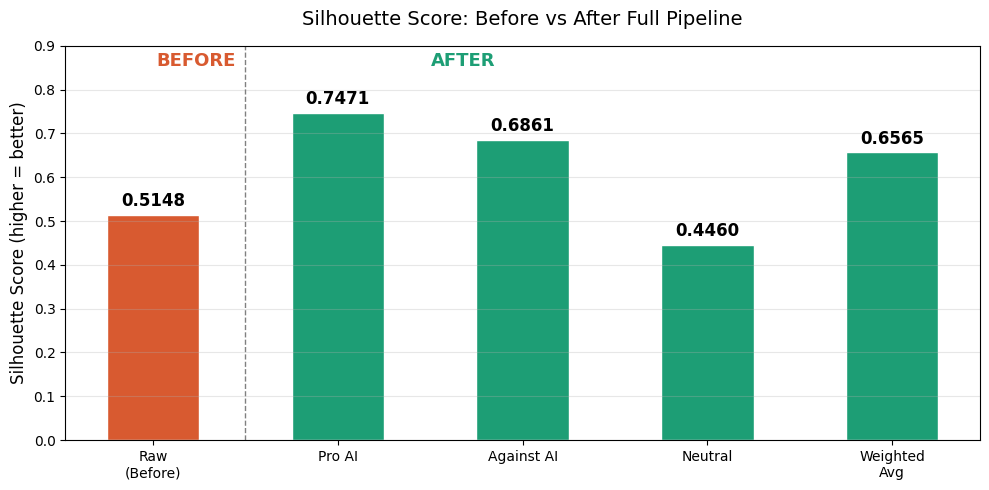

Saved: silhouette_comparison.png


In [87]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Raw\n(Before)', 'Pro AI', 'Against AI', 'Neutral', 'Weighted\nAvg']
values     = [sil_before, sil_pro, sil_against, sil_neutral, sil_after_weighted]
colors     = ['#D85A30', '#1D9E75', '#1D9E75', '#1D9E75', '#1D9E75']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(categories, values, color=colors, width=0.5, edgecolor='white')

# Add value labels on top of bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add vertical divider line
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1)

# Add BEFORE / AFTER labels
ax.text(0.1, 0.95, 'BEFORE', transform=ax.transAxes,
        fontsize=13, color='#D85A30', fontweight='bold')
ax.text(0.4, 0.95, 'AFTER', transform=ax.transAxes,
        fontsize=13, color='#1D9E75', fontweight='bold')

ax.set_title('Silhouette Score: Before vs After Full Pipeline', fontsize=14, pad=15)
ax.set_ylabel('Silhouette Score (higher = better)', fontsize=12)
ax.set_ylim(0, 0.9)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/silhouette_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: silhouette_comparison.png')

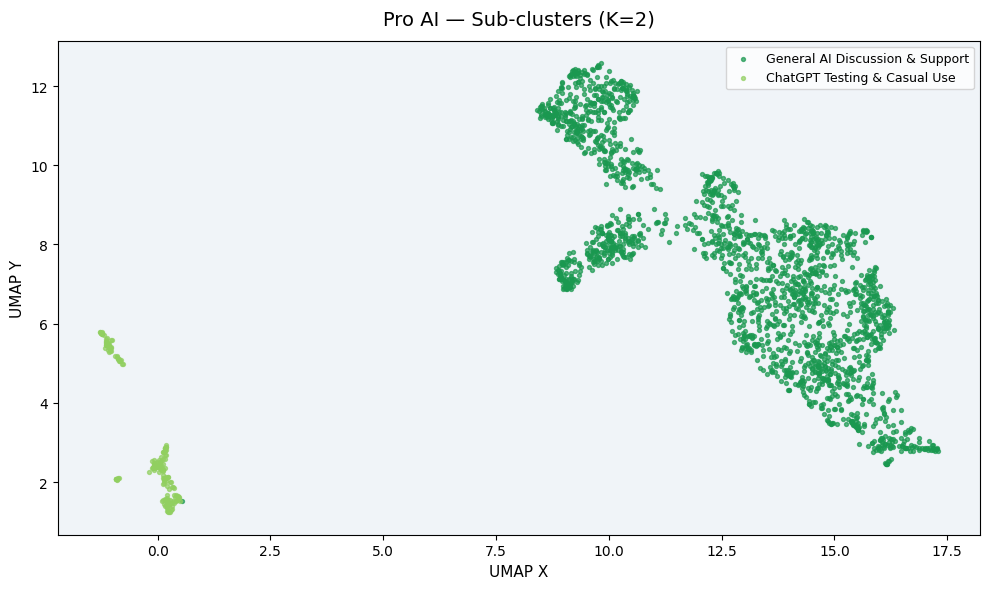

Saved: /kaggle/working/pro_ai_clusters.png


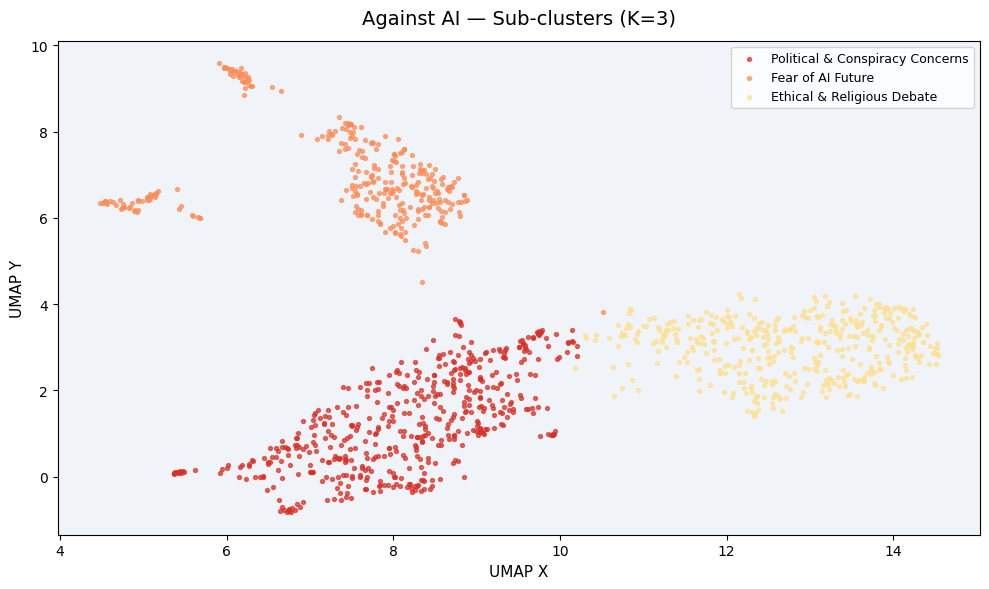

Saved: /kaggle/working/against_ai_clusters.png


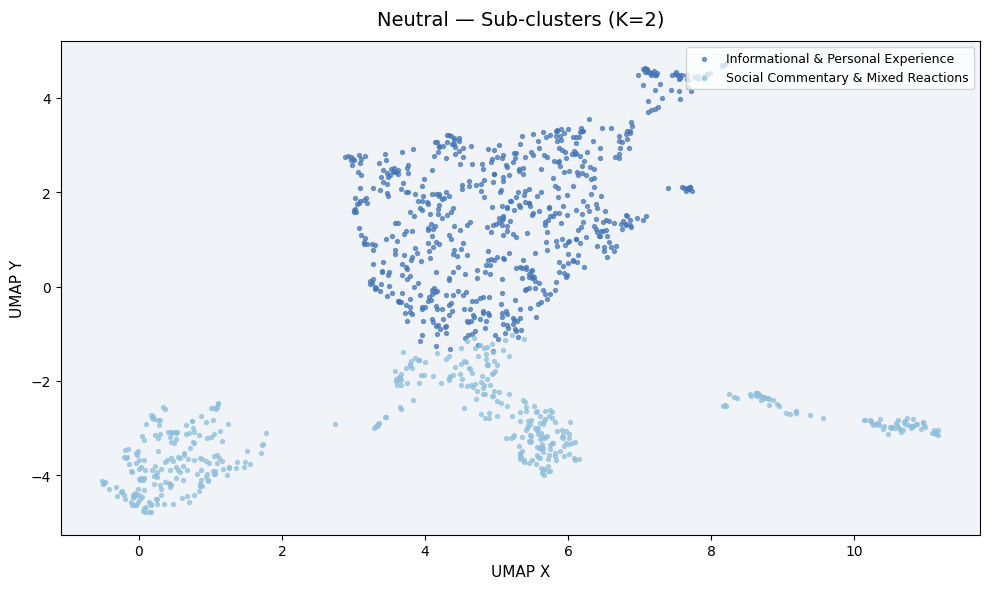

Saved: /kaggle/working/neutral_clusters.png


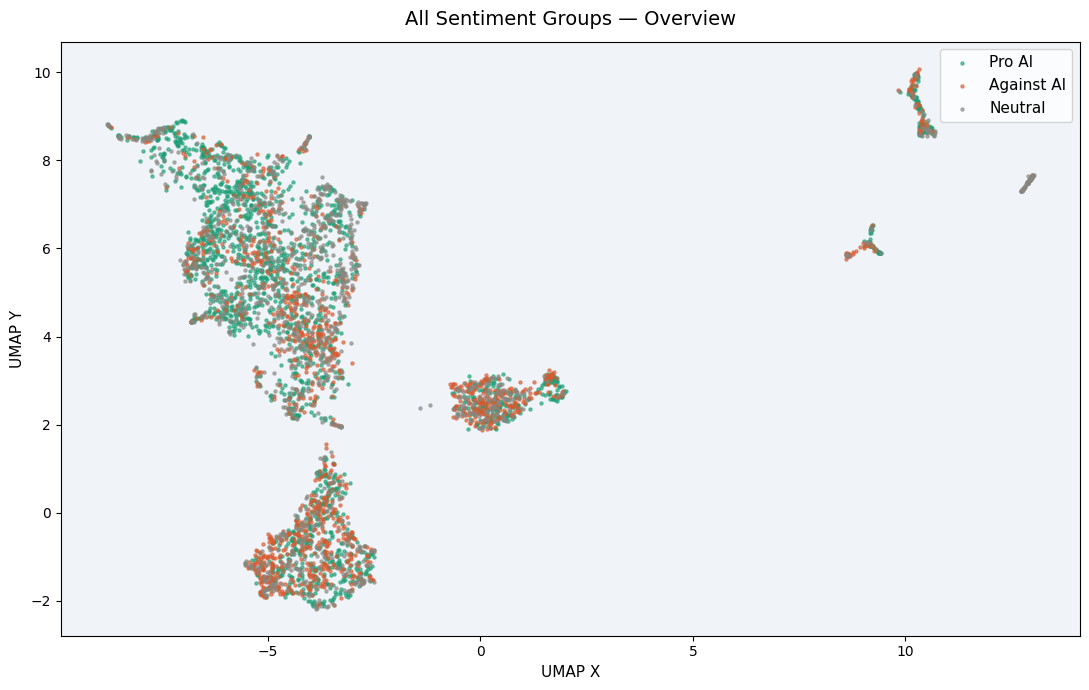

Saved: all_sentiments_overview.png
Saved: all_sentiments_overview.html


In [88]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Color maps updated for optimal K per group
cluster_colors = {
    'Pro AI':     {0: '#1a9850', 1: '#91cf60'},
    'Against AI': {0: '#d73027', 1: '#fc8d59', 2: '#fee090'},
    'Neutral':    {0: '#4575b4', 1: '#91bfdb'}
}

best_k_map = {
    'Pro AI':     best_k_pro,
    'Against AI': best_k_against,
    'Neutral':    best_k_neutral
}

# ── Per sentiment group scatter plots ────────────────────────────────────────
for group_label, df_group in [
    ('Pro AI',     df_pro),
    ('Against AI', df_against),
    ('Neutral',    df_neutral)
]:
    df_group  = df_group.copy()
    colors_map = cluster_colors[group_label]
    best_k    = best_k_map[group_label]

    fig, ax = plt.subplots(figsize=(10, 6))
    for cid in range(best_k):
        mask = df_group['sub_cluster'] == cid
        ax.scatter(
            df_group[mask]['umap_x'],
            df_group[mask]['umap_y'],
            c=colors_map[cid],
            s=8, alpha=0.7,
            label=df_group[mask]['sub_label'].iloc[0] if mask.sum() > 0 else f'Cluster {cid}'
        )
    ax.set_title(f'{group_label} — Sub-clusters (K={best_k})', fontsize=14, pad=12)
    ax.set_xlabel('UMAP X', fontsize=11)
    ax.set_ylabel('UMAP Y', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_facecolor('#f0f4f8')
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    fname = f'/kaggle/working/{group_label.lower().replace(" ", "_")}_clusters.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

# ── Combined overview ─────────────────────────────────────────────────────────
df_pro_tmp     = df_pro.copy();     df_pro_tmp['sentiment']     = 'Pro AI'
df_against_tmp = df_against.copy(); df_against_tmp['sentiment'] = 'Against AI'
df_neutral_tmp = df_neutral.copy(); df_neutral_tmp['sentiment'] = 'Neutral'
df_all = pd.concat([df_pro_tmp, df_against_tmp, df_neutral_tmp], ignore_index=True)

emb_all  = np.vstack([emb_pro, emb_against, emb_neutral])
umap_all = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
coords   = umap_all.fit_transform(emb_all)
df_all['umap_x_all'] = coords[:, 0]
df_all['umap_y_all'] = coords[:, 1]

sentiment_colors = {
    'Pro AI':     '#1D9E75',
    'Against AI': '#D85A30',
    'Neutral':    '#888780'
}

fig, ax = plt.subplots(figsize=(11, 7))
for sentiment, color in sentiment_colors.items():
    mask = df_all['sentiment'] == sentiment
    ax.scatter(
        df_all[mask]['umap_x_all'],
        df_all[mask]['umap_y_all'],
        c=color, s=5, alpha=0.6, label=sentiment
    )
ax.set_title('All Sentiment Groups — Overview', fontsize=14, pad=12)
ax.set_xlabel('UMAP X', fontsize=11)
ax.set_ylabel('UMAP Y', fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.set_facecolor('#f0f4f8')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('/kaggle/working/all_sentiments_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: all_sentiments_overview.png')

# HTML interactive version
df_all['text_short'] = df_all['comment'].str[:80] + '...'
fig_html = px.scatter(
    df_all, x='umap_x_all', y='umap_y_all',
    color='sentiment',
    color_discrete_map=sentiment_colors,
    hover_data=['text_short'],
    title='All Sentiment Groups — Overview',
    width=1000, height=650, opacity=0.65
)
fig_html.update_traces(marker=dict(size=3))
fig_html.write_html('/kaggle/working/all_sentiments_overview.html')
print('Saved: all_sentiments_overview.html')

---
# PHASE G — Save all results

In [89]:
# Add sentiment column to df_all
df_pro['sentiment']     = 'Pro AI'
df_against['sentiment'] = 'Against AI'
df_neutral['sentiment'] = 'Neutral'
df_all = pd.concat([df_pro, df_against, df_neutral], ignore_index=True)

arabic_sentiment_map = {
    'Pro AI':     'مؤيد للذكاء الاصطناعي',
    'Against AI': 'ضد الذكاء الاصطناعي',
    'Neutral':    'محايد'
}
df_all['sentiment_arabic'] = df_all['sentiment'].map(arabic_sentiment_map)

# Save final CSV with all columns
output_cols = [
    'video_url', 'author', 'votes', 'time', 'sort_type',
    'comment', 'text_normalized', 'text_no_stopwords', 'token_count',
    'sentiment_label', 'sentiment_arabic',
    'score_pro_ai', 'score_against_ai', 'score_neutral',
    'sub_cluster', 'sub_label', 'topic_bertopic',
    'umap_x', 'umap_y'
]
output_cols = [c for c in output_cols if c in df_all.columns]
df_all[output_cols].to_csv(
    '/kaggle/working/comments_final.csv',
    index=False, encoding='utf-8-sig'
)

# Save evaluation results including coherence scores
eval_results = pd.DataFrame([
    {'phase': 'BEFORE (raw data)', 'group': 'All comments (raw)',
     'n_comments': len(docs_raw), 'silhouette': round(sil_before,4),
     'davies_bouldin': round(dbi_before,4), 'coherence_cv': None},
    {'phase': 'AFTER clustering',  'group': 'Pro AI',
     'n_comments': n_pro, 'silhouette': round(sil_pro,4),
     'davies_bouldin': round(dbi_pro,4),
     'coherence_cv': coherence_results.get('Pro AI', None)},
    {'phase': 'AFTER clustering',  'group': 'Against AI',
     'n_comments': n_against, 'silhouette': round(sil_against,4),
     'davies_bouldin': round(dbi_against,4),
     'coherence_cv': coherence_results.get('Against AI', None)},
    {'phase': 'AFTER clustering',  'group': 'Neutral',
     'n_comments': n_neutral, 'silhouette': round(sil_neutral,4),
     'davies_bouldin': round(dbi_neutral,4),
     'coherence_cv': coherence_results.get('Neutral', None)},
    {'phase': 'AFTER clustering',  'group': 'Weighted Average',
     'n_comments': n_total, 'silhouette': round(sil_after_weighted,4),
     'davies_bouldin': round(avg_dbi,4), 'coherence_cv': None},
])
eval_results.to_csv('/kaggle/working/evaluation_results.csv', index=False)

print('='*55)
print(' PIPELINE COMPLETE')
print('='*55)
print(f'  Silhouette BEFORE:   {sil_before:.4f}  (raw data)')
print(f'  Silhouette AFTER:    {sil_after_weighted:.4f}  (weighted avg)')
print(f'  Improvement:         +{sil_after_weighted - sil_before:.4f}')
print('='*55)
print()
print('Coherence scores (c_v):')
for group, score in coherence_results.items():
    print(f'  {group:<15}  {score:.4f}')
print()
print('Saved files:')
print('  comments_final.csv              ← 4,651 labeled comments')
print('  comments_with_sentiment.csv     ← 4,651 + sentiment scores')
print('  comments_ai_filtered.csv        ← AI-relevant filtered comments')
print('  evaluation_results.csv          ← silhouette + DBI + coherence')
print('  embeddings_filtered.npy         ← CAMeLBERT vectors')
print('  silhouette_comparison.png       ← before vs after chart')
print('  pro_ai_clusters.png             ← Pro AI scatter')
print('  against_ai_clusters.png         ← Against AI scatter')
print('  neutral_clusters.png            ← Neutral scatter')
print('  all_sentiments_overview.png     ← Combined overview')
print('  bertopic_pro_ai.html            ← BERTopic Pro AI')
print('  bertopic_against_ai.html        ← BERTopic Against AI')
print('  bertopic_neutral.html           ← BERTopic Neutral')
print('  optimal_k.png                   ← Elbow method chart')

 PIPELINE COMPLETE
  Silhouette BEFORE:   0.5148  (raw data)
  Silhouette AFTER:    0.6565  (weighted avg)
  Improvement:         +0.1417

Coherence scores (c_v):
  Pro AI           0.5789
  Against AI       0.4483
  Neutral          0.6322

Saved files:
  comments_final.csv              ← 4,651 labeled comments
  comments_with_sentiment.csv     ← 4,651 + sentiment scores
  comments_ai_filtered.csv        ← AI-relevant filtered comments
  evaluation_results.csv          ← silhouette + DBI + coherence
  embeddings_filtered.npy         ← CAMeLBERT vectors
  silhouette_comparison.png       ← before vs after chart
  pro_ai_clusters.png             ← Pro AI scatter
  against_ai_clusters.png         ← Against AI scatter
  neutral_clusters.png            ← Neutral scatter
  all_sentiments_overview.png     ← Combined overview
  bertopic_pro_ai.html            ← BERTopic Pro AI
  bertopic_against_ai.html        ← BERTopic Against AI
  bertopic_neutral.html           ← BERTopic Neutral
  optimal

In [95]:
print('='*60)
print('REPORT NUMBERS')
print('='*60)
print(f'Raw comments:              {len(docs_raw):,}')
df_cleaned_count = len(pd.read_csv('/kaggle/working/comments_cleaned.csv'))
print(f'Clean comments count: {df_cleaned_count:,}')
print(f'AI-filtered comments:      {n_total:,}')
print()
print(f'Sentiment distribution:')
print(f'  Pro AI:                  {n_pro:,}  ({n_pro/n_total*100:.1f}%)')
print(f'  Against AI:              {n_against:,}  ({n_against/n_total*100:.1f}%)')
print(f'  Neutral:                 {n_neutral:,}  ({n_neutral/n_total*100:.1f}%)')
print()
print(f'Silhouette BEFORE (raw):           {sil_before:.4f}')
print(f'Silhouette BEFORE (AI-filtered):   {sil_clean_before:.4f}')
print(f'Silhouette AFTER  (weighted avg):  {sil_after_weighted:.4f}')
print(f'DBI BEFORE (raw):                  {dbi_before:.4f}')
print(f'DBI BEFORE (AI-filtered):          {dbi_clean_before:.4f}')
print(f'DBI Pro AI:                        {dbi_pro:.4f}')
print(f'DBI Against AI:                    {dbi_against:.4f}')
print(f'DBI Neutral:                       {dbi_neutral:.4f}')
print()
print(f'Optimal K per group:')
print(f'  Pro AI:      K = {best_k_pro}')
print(f'  Against AI:  K = {best_k_against}')
print(f'  Neutral:     K = {best_k_neutral}')
print()
print(f'Coherence (c_v):')
for group, score in coherence_results.items():
    print(f'  {group:<15}  {score:.4f}')
print()
print(f'Sub-cluster sizes:')
for cid in range(best_k_pro):
    print(f'  Pro AI sub-cluster {cid}:      {(df_pro["sub_cluster"]==cid).sum():,}')
for cid in range(best_k_against):
    print(f'  Against AI sub-cluster {cid}:  {(df_against["sub_cluster"]==cid).sum():,}')
for cid in range(best_k_neutral):
    print(f'  Neutral sub-cluster {cid}:     {(df_neutral["sub_cluster"]==cid).sum():,}')

REPORT NUMBERS
Raw comments:              21,739
Clean comments count: 17,944
AI-filtered comments:      4,651

Sentiment distribution:
  Pro AI:                  2,247  (48.3%)
  Against AI:              1,260  (27.1%)
  Neutral:                 1,144  (24.6%)

Silhouette BEFORE (raw):           0.5148
Silhouette BEFORE (AI-filtered):   0.6393
Silhouette AFTER  (weighted avg):  0.6565
DBI BEFORE (raw):                  0.7071
DBI BEFORE (AI-filtered):          0.6696
DBI Pro AI:                        0.3472
DBI Against AI:                    0.4442
DBI Neutral:                       1.0451

Optimal K per group:
  Pro AI:      K = 2
  Against AI:  K = 3
  Neutral:     K = 2

Coherence (c_v):
  Pro AI           0.5789
  Against AI       0.4483
  Neutral          0.6322

Sub-cluster sizes:
  Pro AI sub-cluster 0:      2,061
  Pro AI sub-cluster 1:      186
  Against AI sub-cluster 0:  517
  Against AI sub-cluster 1:  318
  Against AI sub-cluster 2:  425
  Neutral sub-cluster 0:     649


In [96]:
!zip -r working.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/neutral_clusters.png (deflated 7%)
  adding: kaggle/working/comments_final.csv (deflated 79%)
  adding: kaggle/working/eda_basic.png (deflated 16%)
  adding: kaggle/working/against_ai_clusters.png (deflated 6%)
  adding: kaggle/working/embeddings_raw.npy (deflated 8%)
  adding: kaggle/working/bertopic_pro_ai.html (deflated 71%)
  adding: kaggle/working/comments_cleaned.csv (deflated 82%)
  adding: kaggle/working/embeddings_eda.npy (deflated 7%)
  adding: kaggle/working/comments_with_sentiment.csv (deflated 83%)
  adding: kaggle/working/all_sentiments_overview.png (deflated 5%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 73%)
  adding: kaggle/working/silhouette_comparison.png (deflated 17%)
  adding: kaggle/working/comments_ai_filtered.csv (deflated 85%)
  adding: kaggle/working/optimal_k.png (deflated 7%)
  adding: kaggle/working/ev